In [31]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import PowerTransformer
from sklearn.neighbors import NearestNeighbors

In [2]:
df = pd.ExcelFile(r"C:\Users\KIIT\Desktop\ExcelR Data science\Assignments\Clustering\EastWestAirlines.xlsx")

In [3]:
data = pd.read_excel(df, "data")

In [4]:
data.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [5]:
def EDA(data, numerical_cols=None, categorical_cols=None, target=None, 
       plot_all=True, max_categories=20, figsize=(10, 6)):
    """
    Comprehensive Exploratory Data Analysis function
    
    Parameters:
    data (DataFrame): The pandas DataFrame to analyze
    numerical_cols (list, optional): List of numerical columns to analyze. If None, auto-detected.
    categorical_cols (list, optional): List of categorical columns to analyze. If None, auto-detected.
    target (str, optional): Target variable name if applicable
    plot_all (bool): Whether to generate all plots
    max_categories (int): Maximum number of categories to plot for categorical variables
    figsize (tuple): Default figure size for plots
    """
    
    # Set better aesthetics for plots
    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = figsize
    
    #-------------- BASIC DATASET INFORMATION --------------#
    print("="*50)
    print("BASIC DATASET INFORMATION")
    print("="*50)
    print("SHAPE:", data.shape, "\n")
    print("INFO:")
    print(data.info(), "\n")
    print("STATISTICAL SUMMARY:")
    print(data.describe(), "\n")
    
    #-------------- MISSING VALUES ANALYSIS --------------#
    print("="*50)
    print("MISSING VALUES ANALYSIS")
    print("="*50)
    missing = data.isnull().sum()
    print("Missing Values:")
    print(missing, "\n")
    
    # Better missing values visualization
    plt.figure(figsize=(12, 6))
    missing = missing.sort_values(ascending=False)
    missing = missing[missing > 0]
    if not missing.empty:
        missing_percent = (missing / len(data)) * 100
        missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_percent})
        ax = missing_df['Percent'].plot(kind='bar', figsize=(12, 6), color='coral')
        plt.title('Percentage of Missing Values')
        plt.ylabel('Percentage')
        for i, v in enumerate(missing_percent):
            plt.text(i, v + 1, f"{v:.1f}%", ha='center')
        plt.tight_layout()
        plt.show()
    else:
        print("No missing values in the dataset")
    
    # Visualize missing value patterns
    if data.isnull().sum().sum() > 0:
        plt.figure(figsize=(12, 8))
        sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
        plt.title('Missing Value Pattern')
        plt.tight_layout()
        plt.show()
    
    #-------------- DUPLICATE CHECK --------------#
    print("="*50)
    print("DUPLICATE CHECK")
    print("="*50)
    duplicates = data.duplicated().sum()
    print(f"Duplicate rows: {duplicates} ({duplicates/len(data)*100:.2f}%)\n")
    
    #-------------- IDENTIFY COLUMN TYPES --------------#
    # Use provided columns or auto-detect
    if numerical_cols is None:
        Numerical_columns = data.select_dtypes(include=['number'])
    else:
        Numerical_columns = data[numerical_cols]
        
    if categorical_cols is None:
        categorical_columns = data.select_dtypes(include=['object', 'category', 'bool'])
    else:
        categorical_columns = data[categorical_cols]
    
    print(f"Numerical columns ({len(Numerical_columns.columns)}): {list(Numerical_columns.columns)}")
    print(f"Categorical columns ({len(categorical_columns.columns)}): {list(categorical_columns.columns)}\n")
    
    #-------------- NUMERICAL DATA ANALYSIS --------------#
    if not Numerical_columns.empty:
        print("="*50)
        print("NUMERICAL DATA ANALYSIS")
        print("="*50)
        
        # Distribution of numerical variables
        for column in Numerical_columns:
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            sns.histplot(data=data, x=column, bins=30, kde=True, color='orange', alpha=0.7)
            plt.title(f"Histogram of {column}")
            plt.xlabel(f"{column}")
            plt.ylabel("Frequency")
            
            plt.subplot(1, 2, 2)
            sns.boxplot(x=data[column])
            plt.title(f'Boxplot for {column} - Outlier Check')
            plt.tight_layout()
            plt.show()
            
            # Calculate and display outliers using IQR
            Q1 = data[column].quantile(0.25)
            Q3 = data[column].quantile(0.75)
            IQR = Q3 - Q1
            outliers = data[(data[column] < (Q1 - 1.5 * IQR)) | (data[column] > (Q3 + 1.5 * IQR))][column]
            print(f"Outliers in {column}: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
        
        # Correlation analysis
        if len(Numerical_columns.columns) > 1:
            print("\nCorrelation Analysis:")
            correlation = Numerical_columns.corr()
            plt.figure(figsize=(max(10, len(Numerical_columns.columns)*1.5), 
                               max(8, len(Numerical_columns.columns)*1.2)))
            plt.title("Correlation Matrix")
            heatmap = sns.heatmap(correlation, cmap='YlGnBu', annot=True, linewidth=0.5, fmt=".2f")
            plt.tight_layout()
            plt.show()
            
            # Identify highest correlations
            corr_pairs = correlation.unstack().sort_values(ascending=False)
            # Remove self-correlations
            corr_pairs = corr_pairs[corr_pairs < 1.0]
            high_corr = corr_pairs[abs(corr_pairs) > 0.5]
            if not high_corr.empty:
                print("\nHighest Correlations:")
                print(high_corr.head(10))
    
    #-------------- CATEGORICAL DATA ANALYSIS --------------#
    if not categorical_columns.empty:
        print("\n" + "="*50)
        print("CATEGORICAL DATA ANALYSIS")
        print("="*50)
        
        for column in categorical_columns:
            value_counts = data[column].value_counts()
            n_unique = data[column].nunique()
            print(f"\n{column}: {n_unique} unique values")
            
            if n_unique <= max_categories:
                print(value_counts)
                
                plt.figure(figsize=(12, min(8, max(4, n_unique*0.4))))
                ax = sns.countplot(y=column, data=data, order=value_counts.index)
                plt.title(f'Count Plot of {column}')
                
                # Add percentage annotations
                total = len(data)
                for p in ax.patches:
                    percentage = f'{100 * p.get_width() / total:.1f}%'
                    x = p.get_width() + (total * 0.01)
                    y = p.get_y() + p.get_height() / 2
                    ax.annotate(percentage, (x, y))
                
                plt.tight_layout()
                plt.show()
            else:
                print(f"Too many categories ({n_unique}) to display. Top 10:")
                print(value_counts.head(10))
    
    #-------------- BIVARIATE ANALYSIS --------------#
    if plot_all and not Numerical_columns.empty:
        print("\n" + "="*50)
        print("BIVARIATE ANALYSIS")
        print("="*50)
        
        # Relationships between numerical variables
        if len(Numerical_columns.columns) > 1:
            print("\nPairplot of Numerical Features:")
            sns.pairplot(data[Numerical_columns.columns], diag_kind='kde')
            plt.suptitle('Pair Plot of Numerical Features', y=1.02)
            plt.show()
        
        # Relationship between categorical and numerical
        if not categorical_columns.empty and not Numerical_columns.empty:
            print("\nRelationship between Key Categorical and Numerical Variables:")
            for cat_col in categorical_columns.columns[:min(3, len(categorical_columns.columns))]:
                # Only plot if reasonable number of categories
                if data[cat_col].nunique() <= 10:
                    for num_col in Numerical_columns.columns[:min(3, len(Numerical_columns.columns))]:
                        plt.figure(figsize=(12, 6))
                        sns.boxplot(x=cat_col, y=num_col, data=data)
                        plt.title(f'Relationship: {cat_col} vs {num_col}')
                        plt.xticks(rotation=45)
                        plt.tight_layout()
                        plt.show()
    
    #-------------- STATISTICAL TESTS --------------#
    if plot_all and not Numerical_columns.empty:
        print("\n" + "="*50)
        print("DISTRIBUTION ANALYSIS")
        print("="*50)
        
        # Test for normality
        for column in Numerical_columns:
            # Only test if there's a reasonable number of values
            if len(data[column].dropna()) > 5:
                try:
                    stat, p_value = stats.shapiro(data[column].dropna().sample(min(5000, len(data[column].dropna()))))
                    alpha = 0.05
                    print(f"Shapiro-Wilk Test for {column}:")
                    print(f"p-value: {p_value:.4f}")
                    if p_value > alpha:
                        print(f"{column} appears to be normally distributed (fail to reject H0)")
                    else:
                        print(f"{column} does not appear to be normally distributed (reject H0)")
                    print()
                    
                    # QQ Plot for visual normality check
                    plt.figure(figsize=(10, 6))
                    stats.probplot(data[column].dropna(), plot=plt)
                    plt.title(f'Q-Q Plot for {column}')
                    plt.tight_layout()
                    plt.show()
                except Exception as e:
                    print(f"Could not perform normality test for {column}: {e}")
    
    #-------------- SUMMARY STATISTICS BY CATEGORY --------------#
    if target is not None and target in data.columns:
        print("\n" + "="*50)
        print(f"SUMMARY STATISTICS BY TARGET: {target}")
        print("="*50)
        print(data.groupby(target)[Numerical_columns.columns].describe())
    elif not categorical_columns.empty and not Numerical_columns.empty:
        # Pick first categorical column with reasonable number of categories
        for cat_col in categorical_columns.columns:
            if data[cat_col].nunique() <= 5:
                print("\n" + "="*50)
                print(f"SUMMARY STATISTICS GROUPED BY {cat_col}")
                print("="*50)
                print(data.groupby(cat_col)[Numerical_columns.columns].describe())
                break
    
    #-------------- FEATURE ENGINEERING PREVIEW --------------#
    if plot_all and not Numerical_columns.empty:
        print("\n" + "="*50)
        print("FEATURE ENGINEERING INSIGHTS")
        print("="*50)
        
        # Show skewness and kurtosis
        print("\nSkewness of Numerical Features:")
        print(Numerical_columns.skew())

        print("\nKurtosis of Numerical Features:")
        print(Numerical_columns.kurtosis())

        # Log transformation preview for skewed features
        for column in Numerical_columns.columns:
            if abs(data[column].skew()) > 1:  # If skewed
                plt.figure(figsize=(12, 5))
                
                plt.subplot(1, 2, 1)
                sns.histplot(data[column], kde=True)
                plt.title(f'Original Distribution of {column} (Skewness: {data[column].skew():.2f})')
                
                plt.subplot(1, 2, 2)
                # Apply log transformation (handling zeros/negatives)
                if (data[column] <= 0).any():
                    transformed = np.log1p(data[column] - data[column].min() + 1)
                    title = f'Log1p Transformed {column}'
                else:
                    transformed = np.log1p(data[column])
                    title = f'Log1p Transformed {column}'
                    
                sns.histplot(transformed, kde=True)
                plt.title(f'{title} (Skewness: {transformed.skew():.2f})')
                
                plt.tight_layout()
                plt.show()
                
    print("\n" + "="*50)
    print("EDA COMPLETED")
    print("="*50)
    
    return {
        "shape": data.shape,
        "missing": data.isnull().sum(),
        "duplicates": duplicates,
        "numerical_columns": list(Numerical_columns.columns),
        "categorical_columns": list(categorical_columns.columns)
    }


BASIC DATASET INFORMATION
SHAPE: (3999, 12) 

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB
None 

STATISTICAL SUMMARY:
               ID#       Balance    Qual_miles    cc1_miles    cc2_miles  \
count  3999.000000  3.999000e+03   3999.000000  3999

<Figure size 1200x600 with 0 Axes>

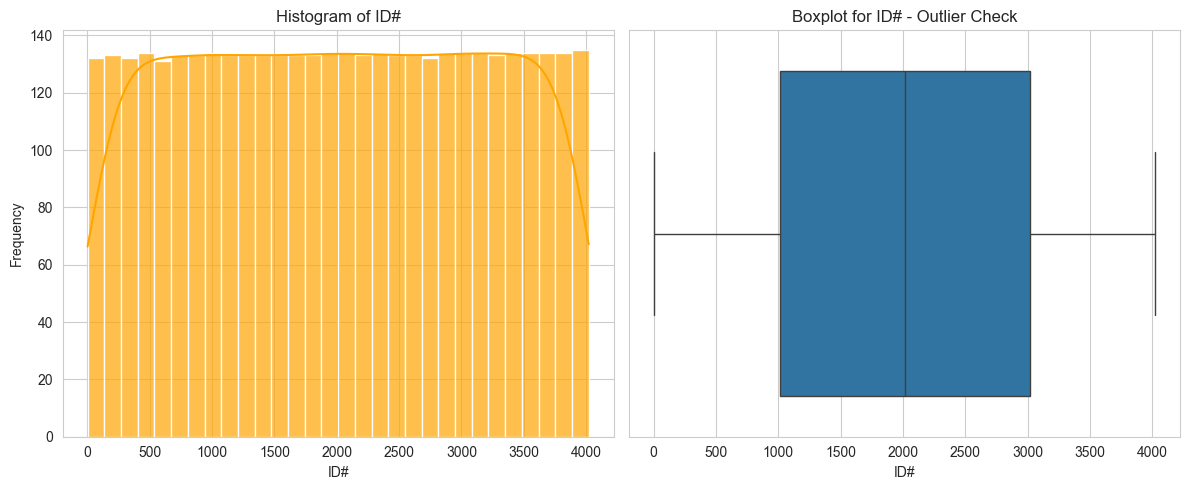

Outliers in ID#: 0 (0.00%)


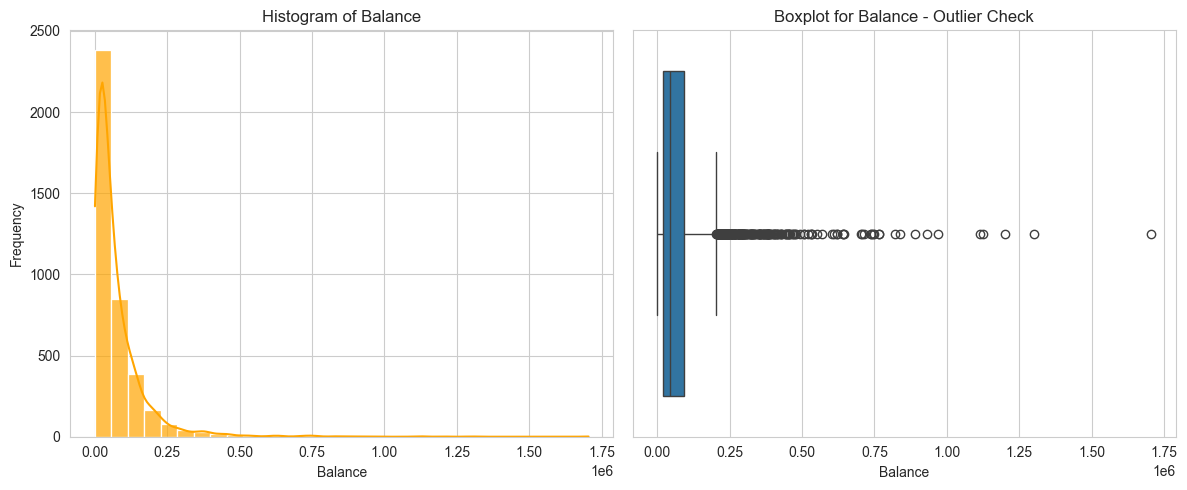

Outliers in Balance: 266 (6.65%)


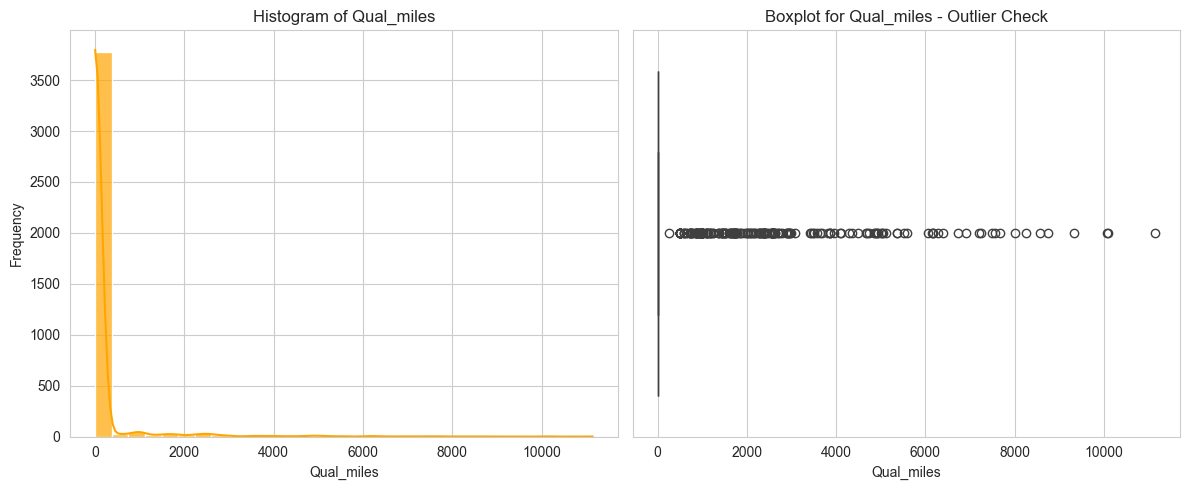

Outliers in Qual_miles: 226 (5.65%)


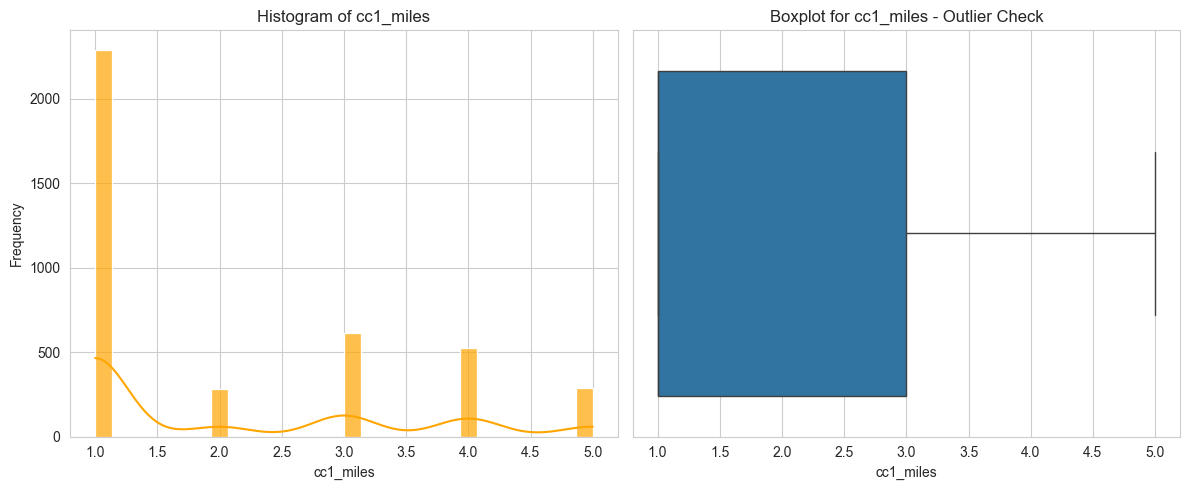

Outliers in cc1_miles: 0 (0.00%)


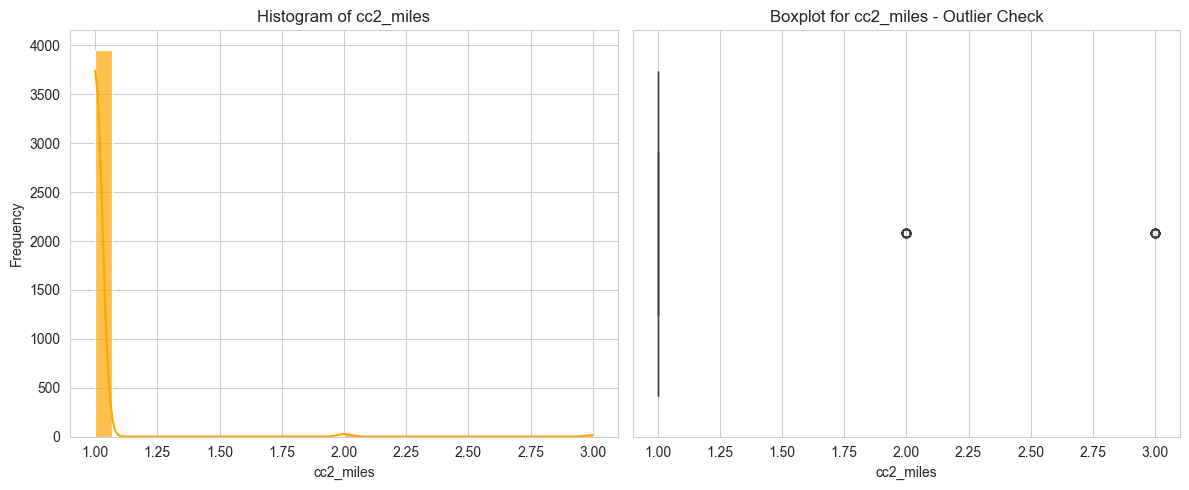

Outliers in cc2_miles: 43 (1.08%)


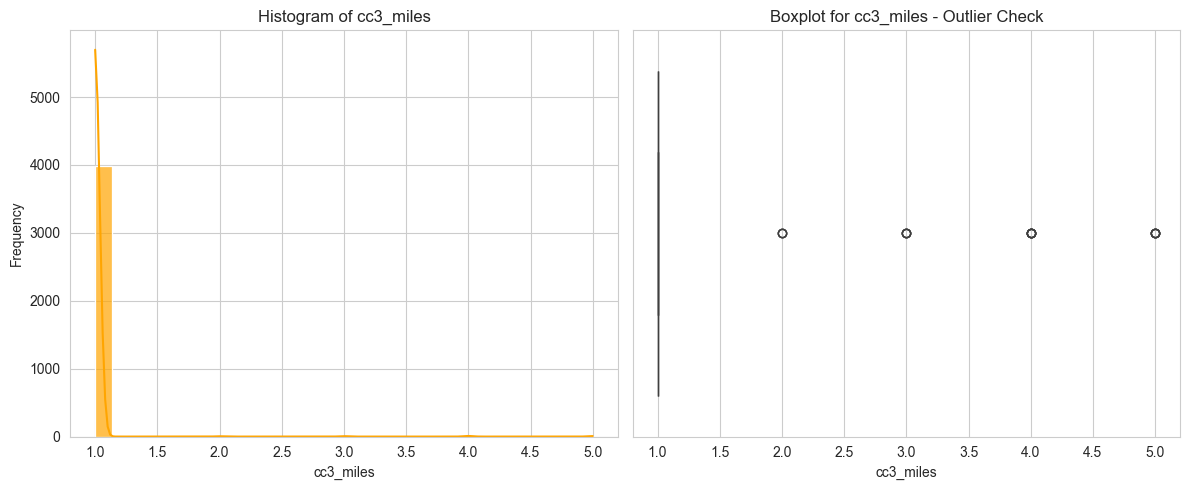

Outliers in cc3_miles: 18 (0.45%)


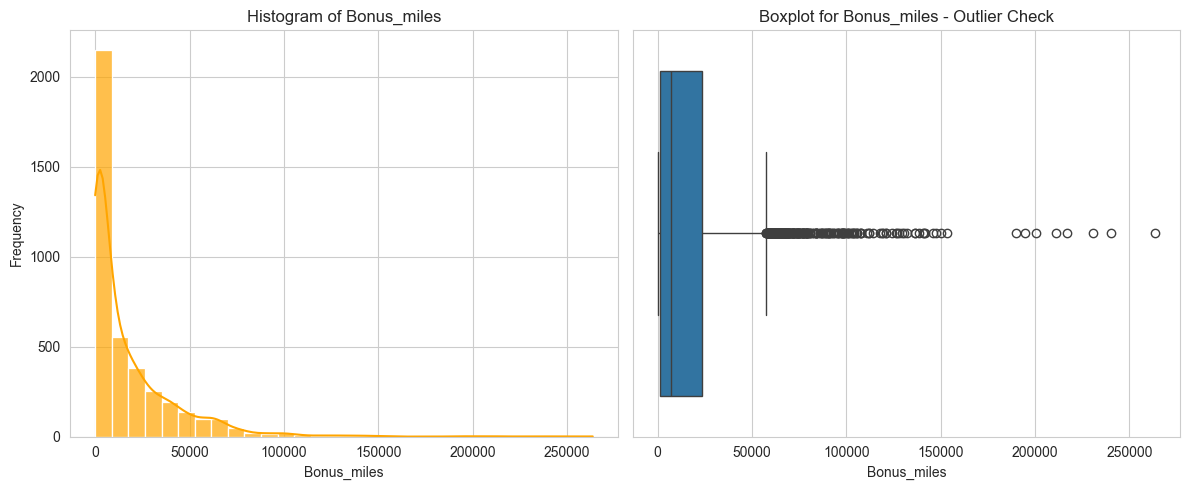

Outliers in Bonus_miles: 280 (7.00%)


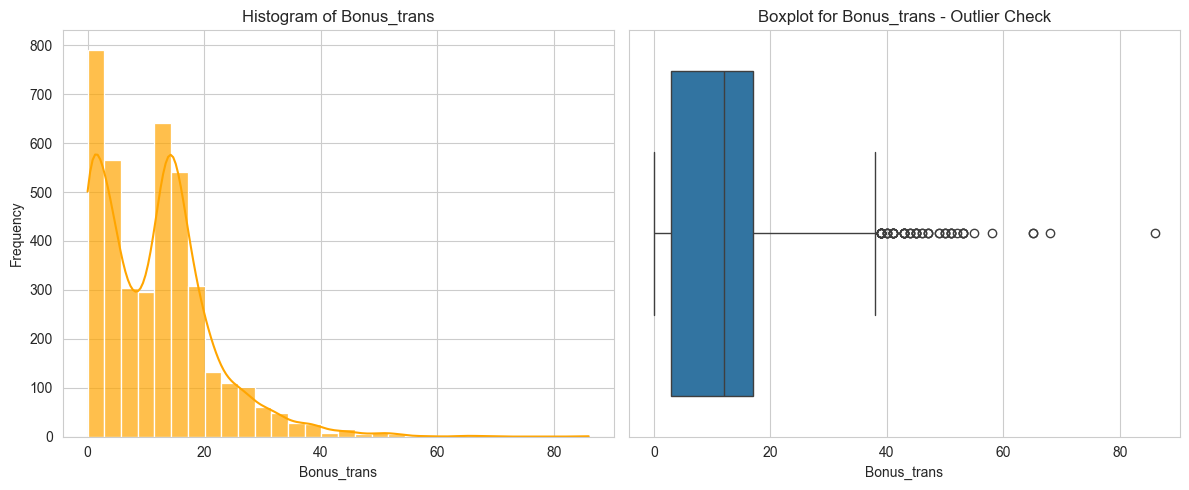

Outliers in Bonus_trans: 63 (1.58%)


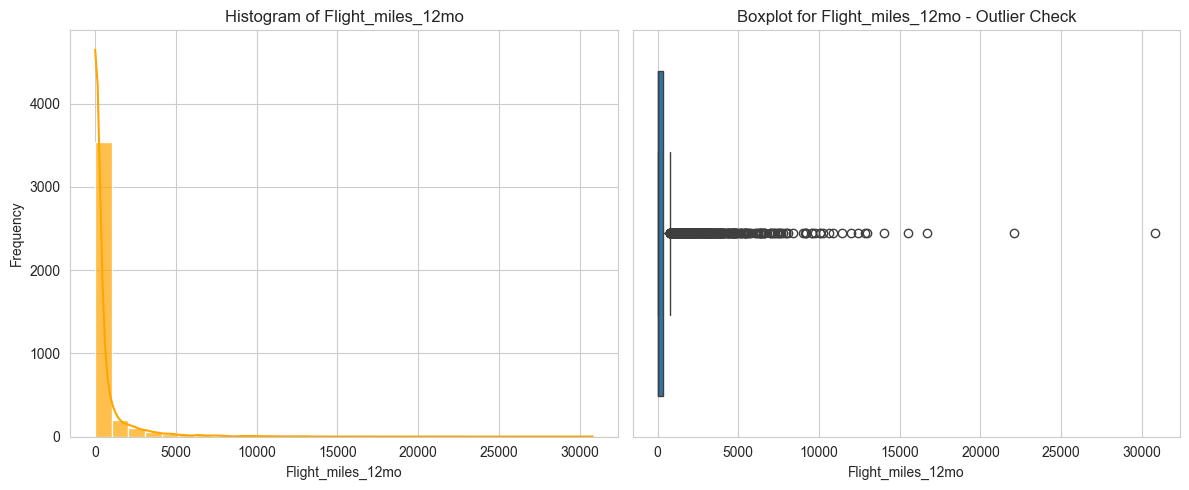

Outliers in Flight_miles_12mo: 569 (14.23%)


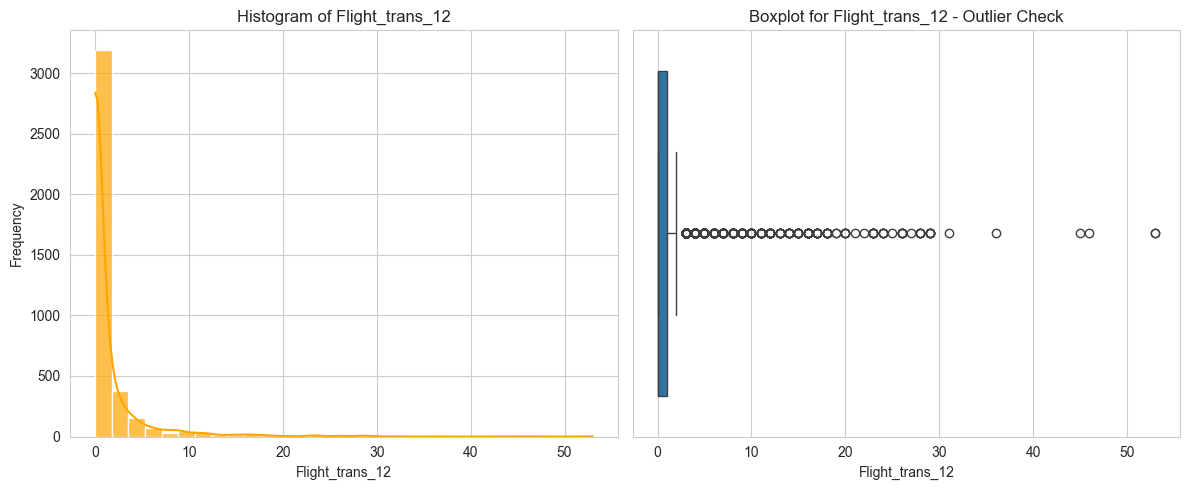

Outliers in Flight_trans_12: 565 (14.13%)


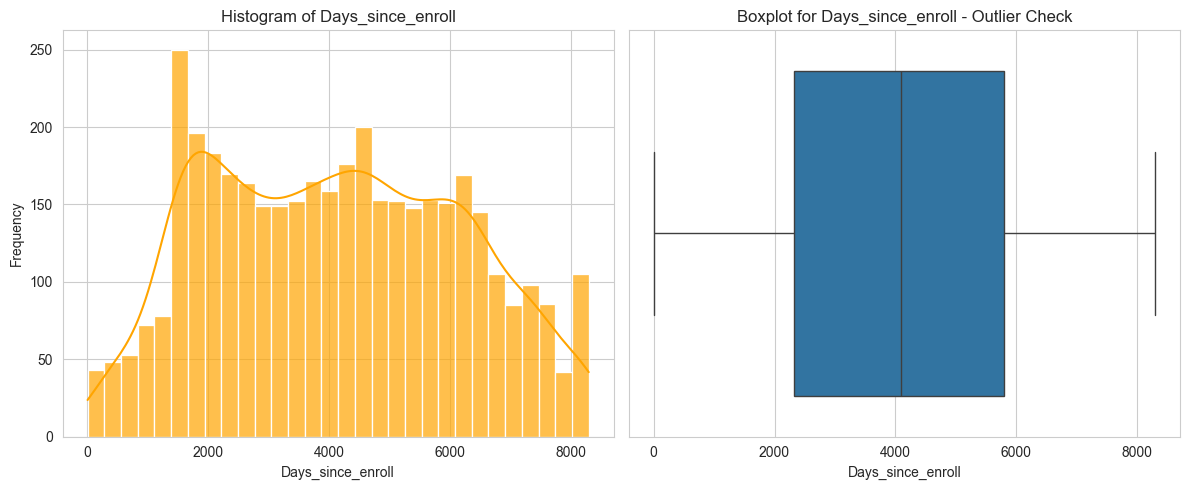

Outliers in Days_since_enroll: 0 (0.00%)


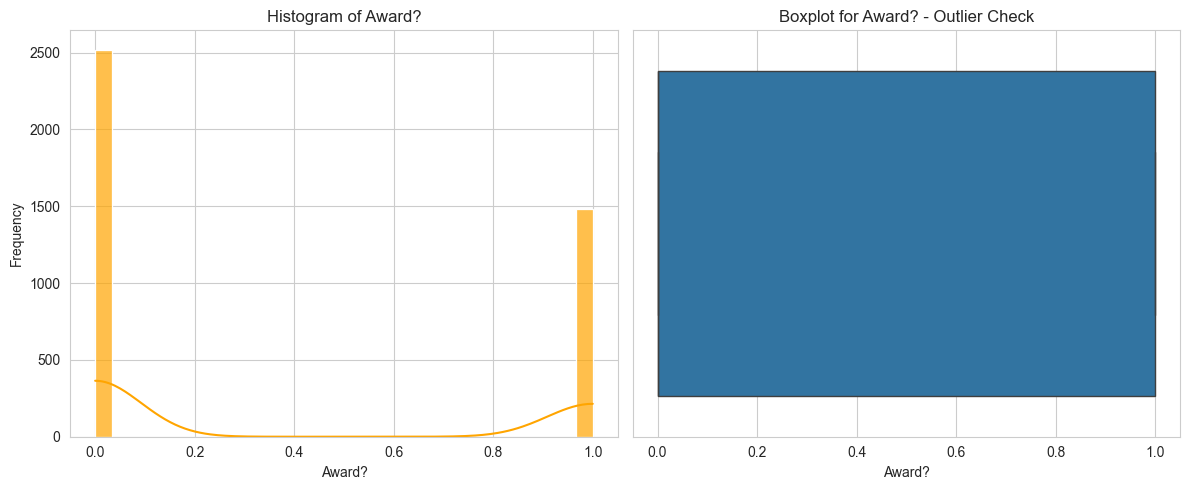

Outliers in Award?: 0 (0.00%)

Correlation Analysis:


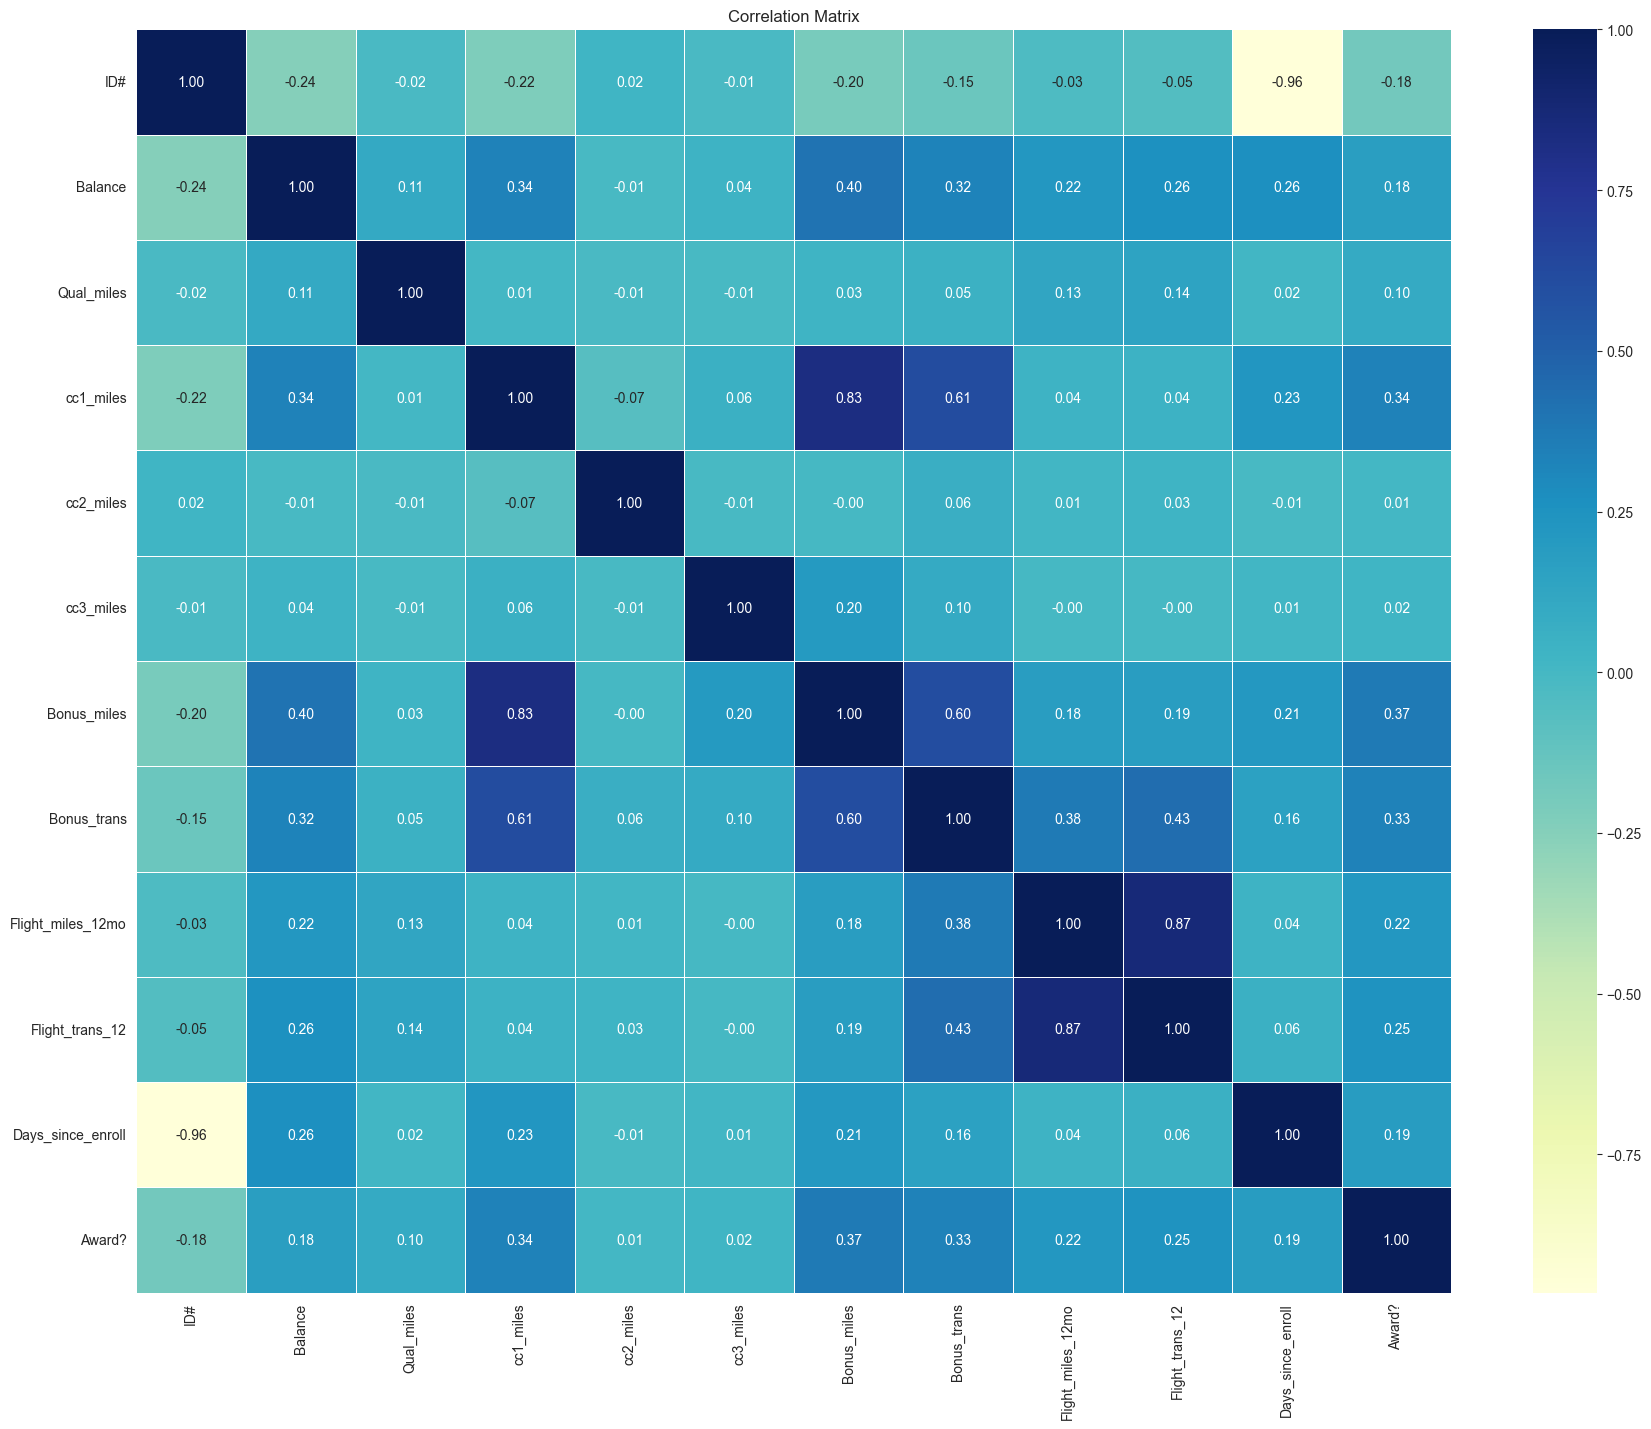


Highest Correlations:
Flight_miles_12mo  Flight_trans_12      0.869193
Flight_trans_12    Flight_miles_12mo    0.869193
cc1_miles          Bonus_miles          0.825200
Bonus_miles        cc1_miles            0.825200
Bonus_trans        cc1_miles            0.608943
cc1_miles          Bonus_trans          0.608943
Bonus_trans        Bonus_miles          0.603180
Bonus_miles        Bonus_trans          0.603180
Days_since_enroll  ID#                 -0.964988
ID#                Days_since_enroll   -0.964988
dtype: float64

BIVARIATE ANALYSIS

Pairplot of Numerical Features:


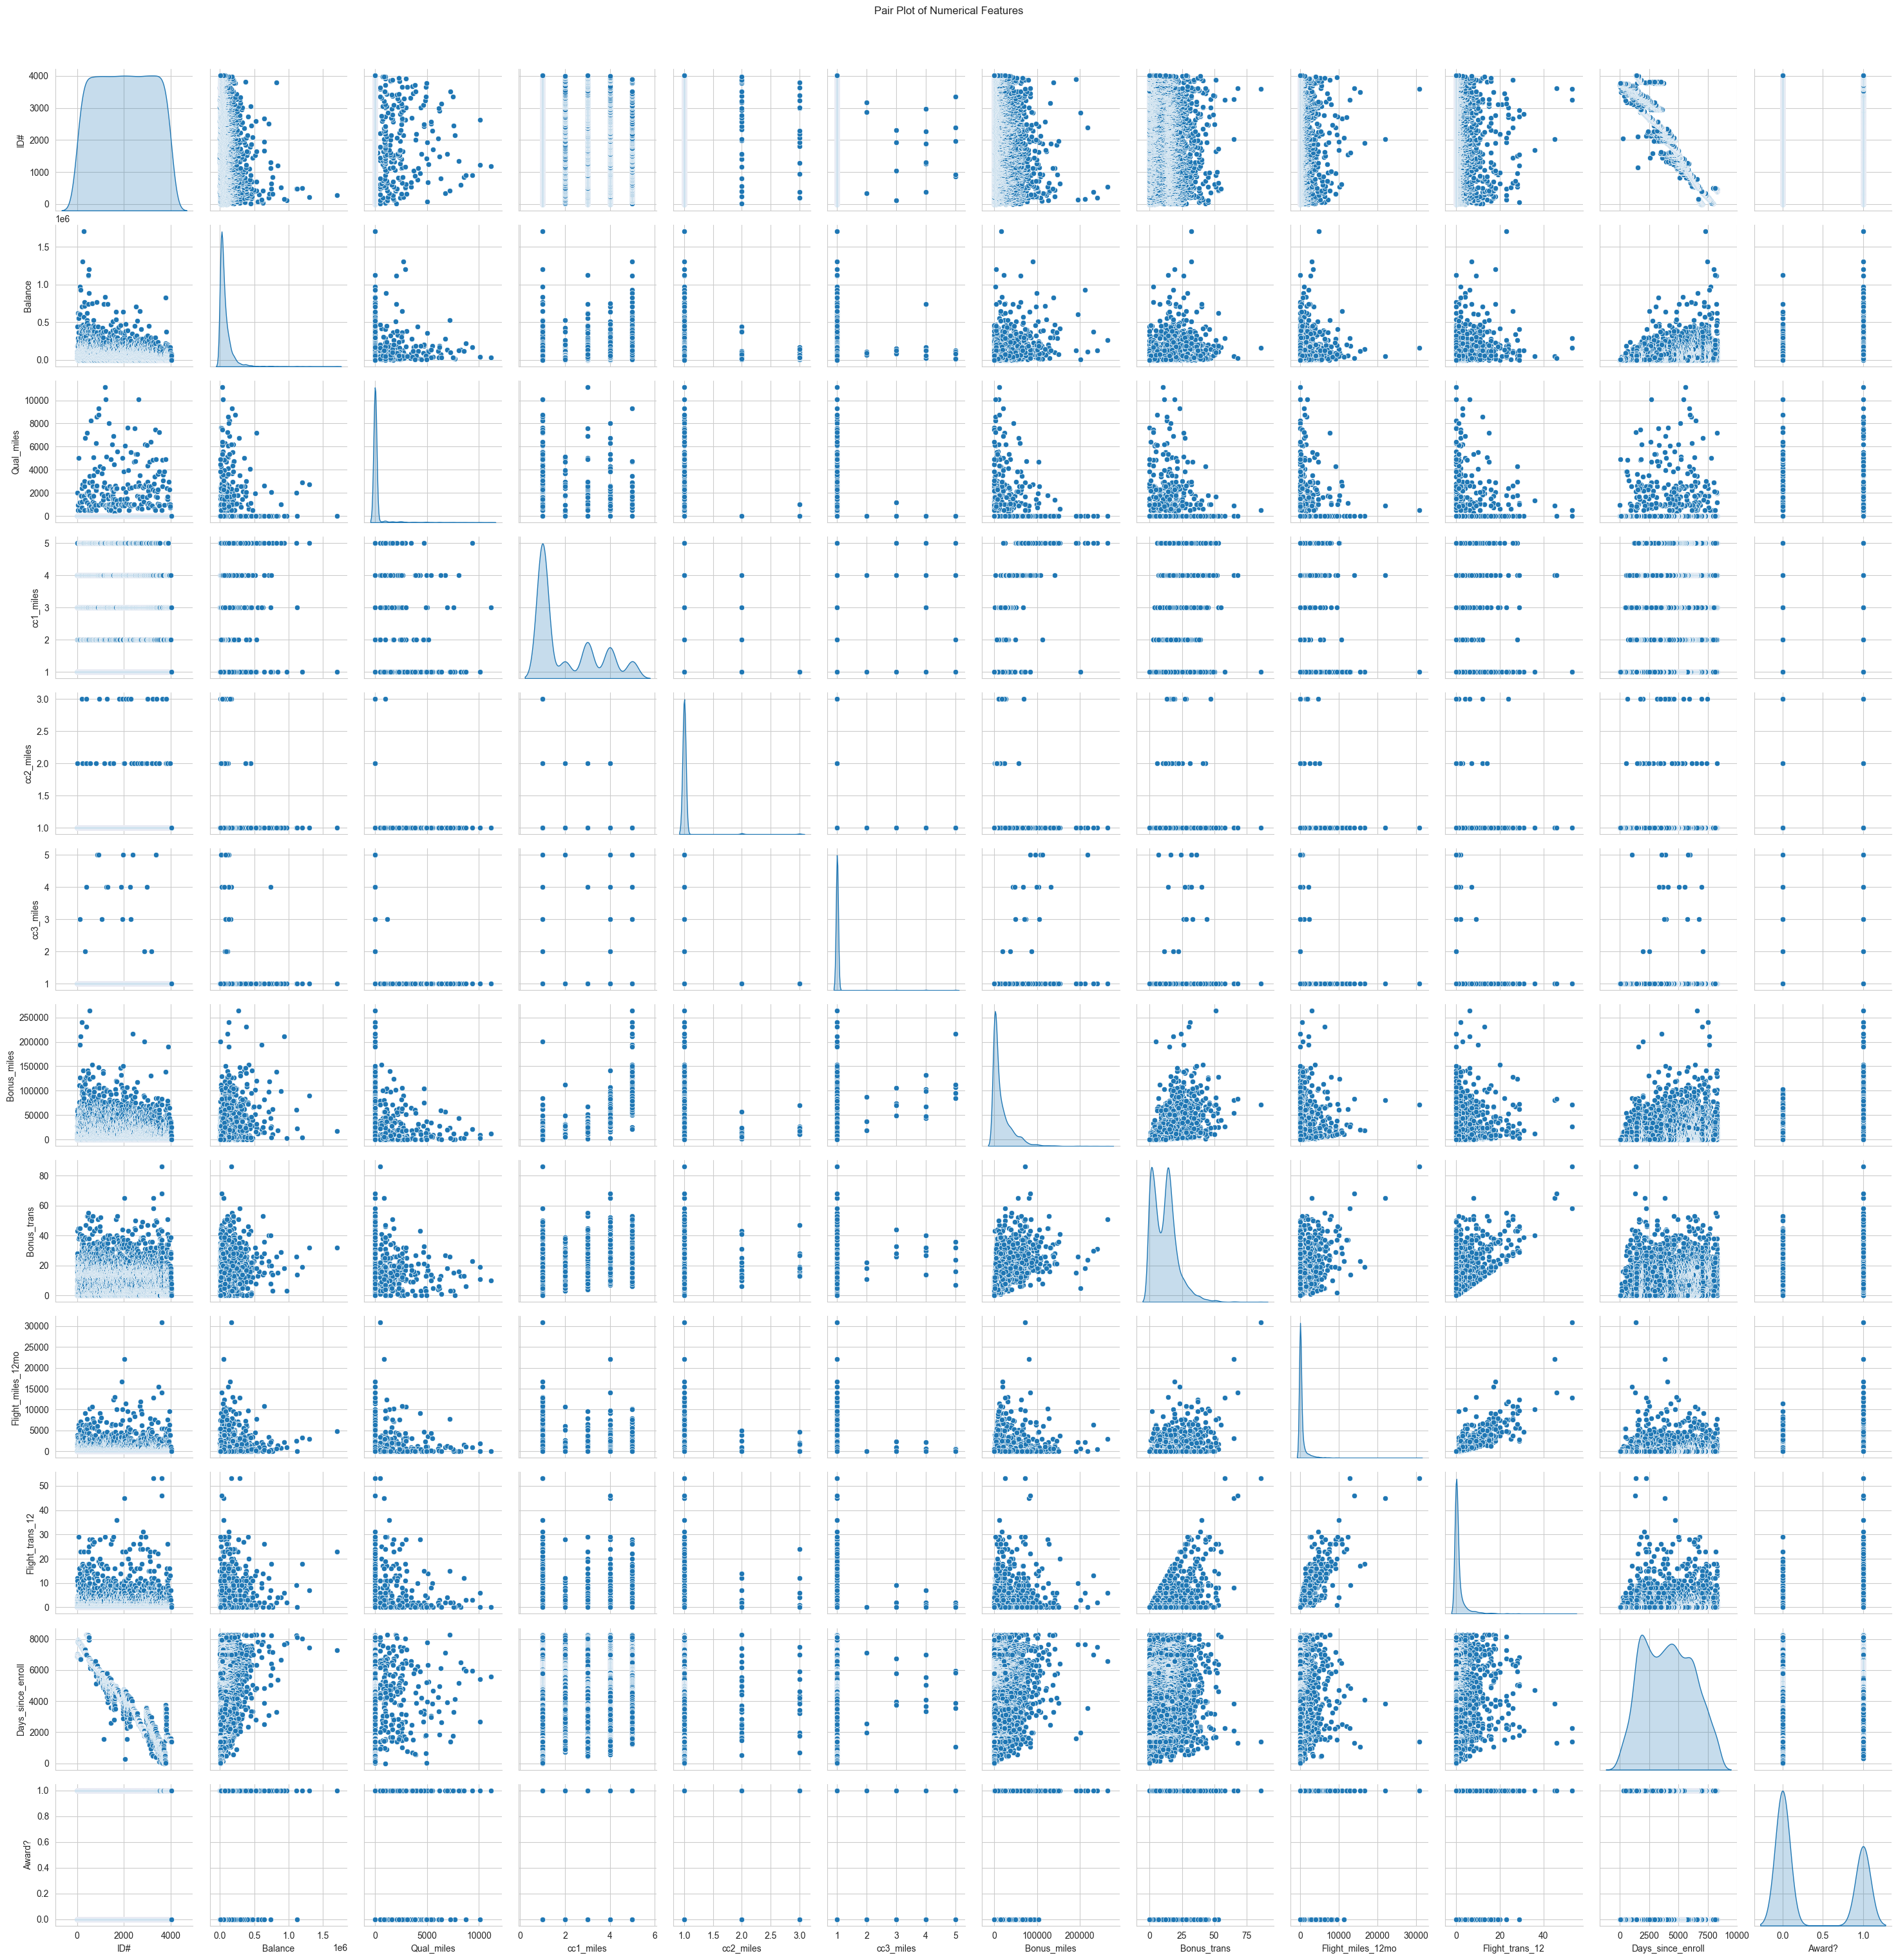


DISTRIBUTION ANALYSIS
Shapiro-Wilk Test for ID#:
p-value: 0.0000
ID# does not appear to be normally distributed (reject H0)



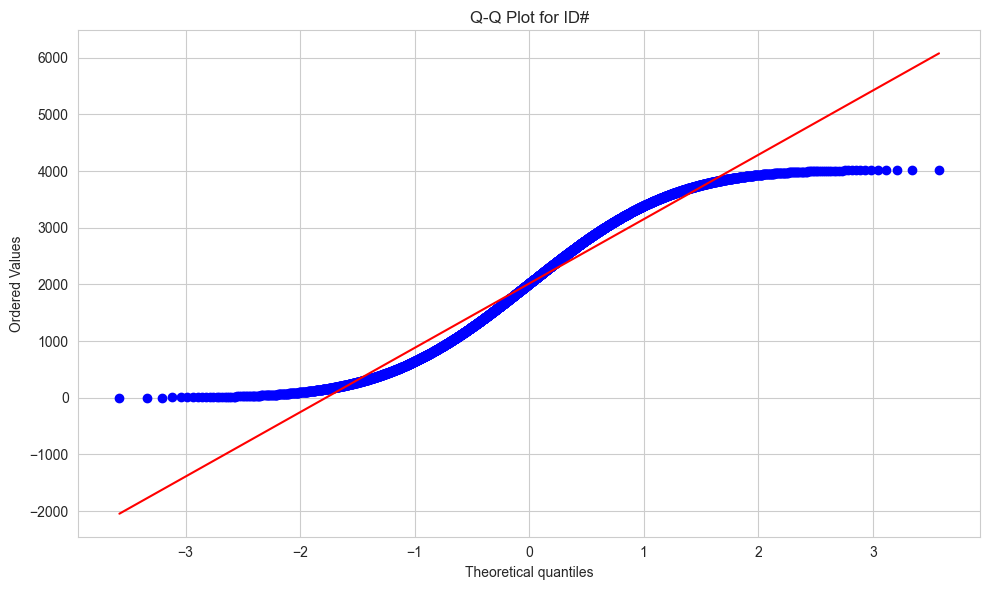

Shapiro-Wilk Test for Balance:
p-value: 0.0000
Balance does not appear to be normally distributed (reject H0)



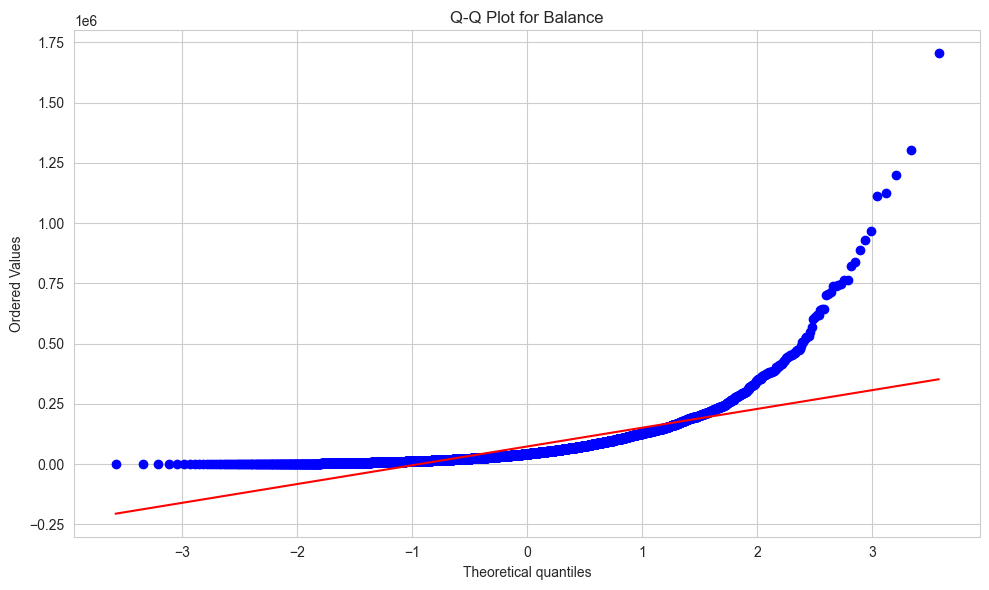

Shapiro-Wilk Test for Qual_miles:
p-value: 0.0000
Qual_miles does not appear to be normally distributed (reject H0)



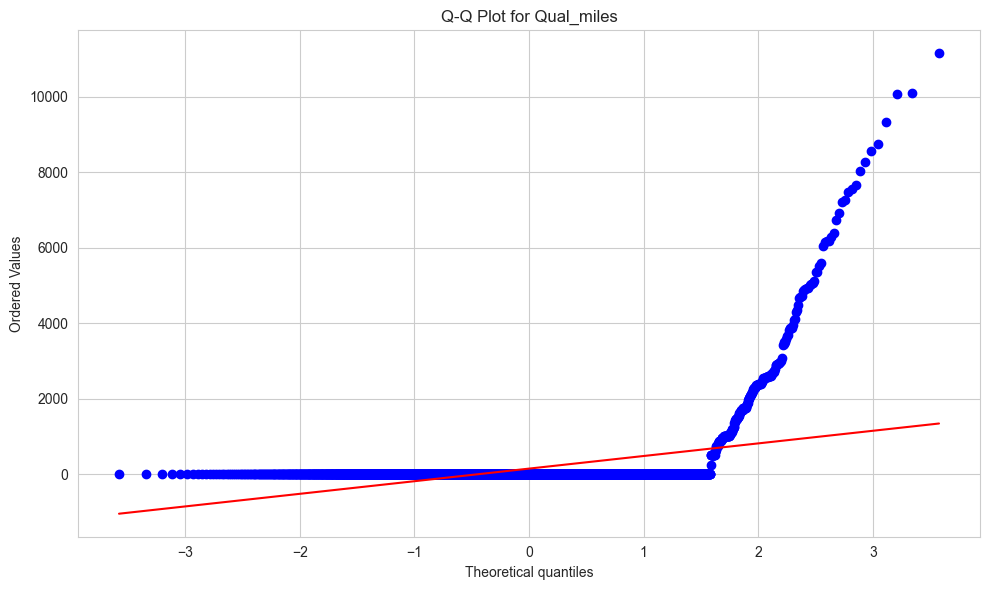

Shapiro-Wilk Test for cc1_miles:
p-value: 0.0000
cc1_miles does not appear to be normally distributed (reject H0)



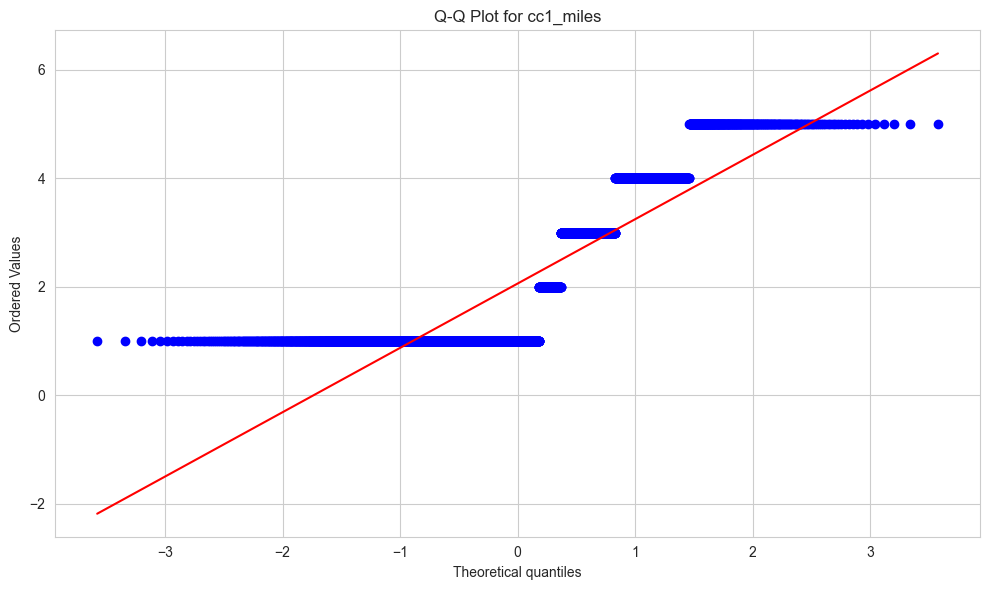

Shapiro-Wilk Test for cc2_miles:
p-value: 0.0000
cc2_miles does not appear to be normally distributed (reject H0)



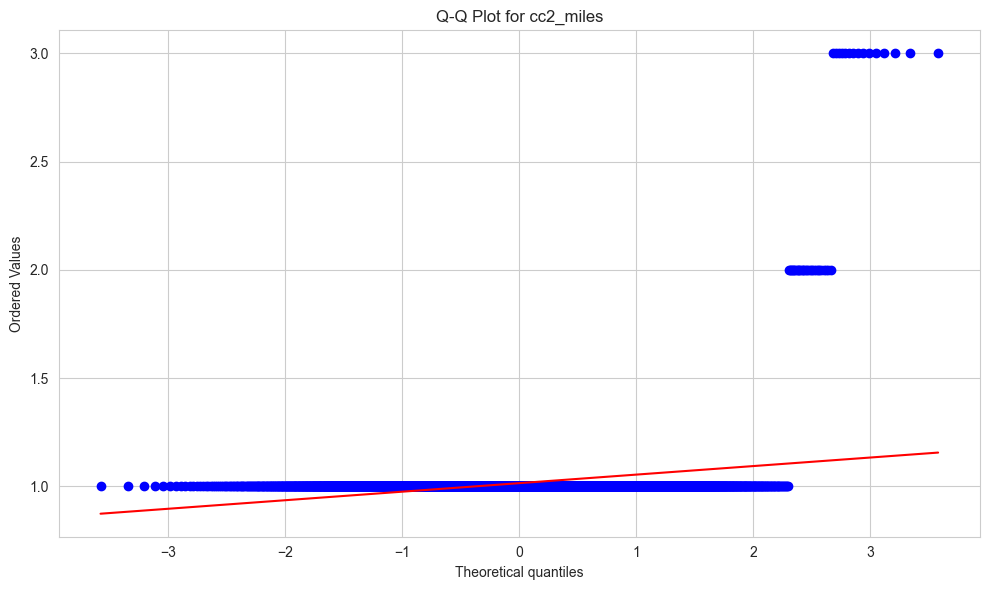

Shapiro-Wilk Test for cc3_miles:
p-value: 0.0000
cc3_miles does not appear to be normally distributed (reject H0)



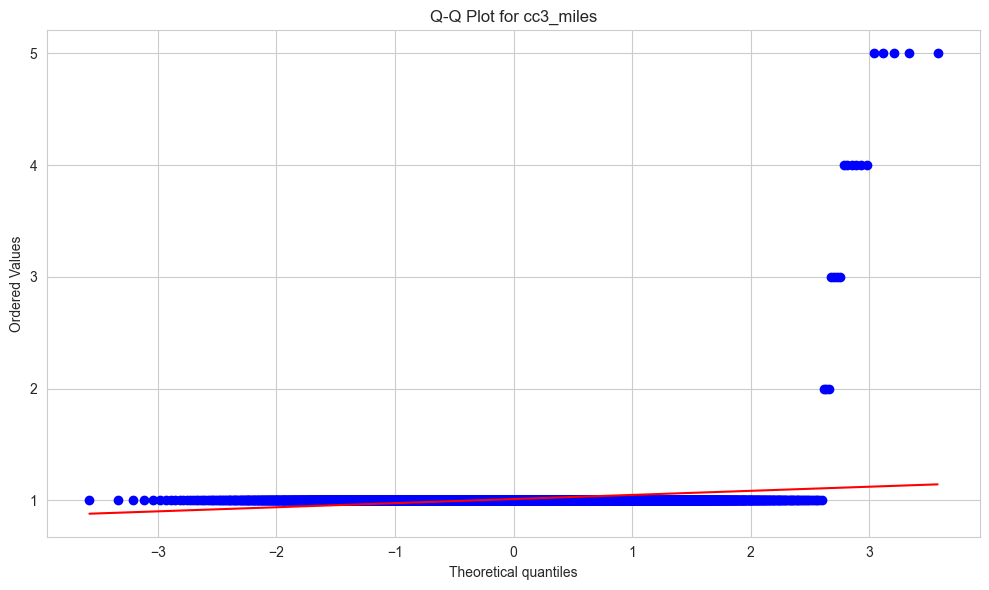

Shapiro-Wilk Test for Bonus_miles:
p-value: 0.0000
Bonus_miles does not appear to be normally distributed (reject H0)



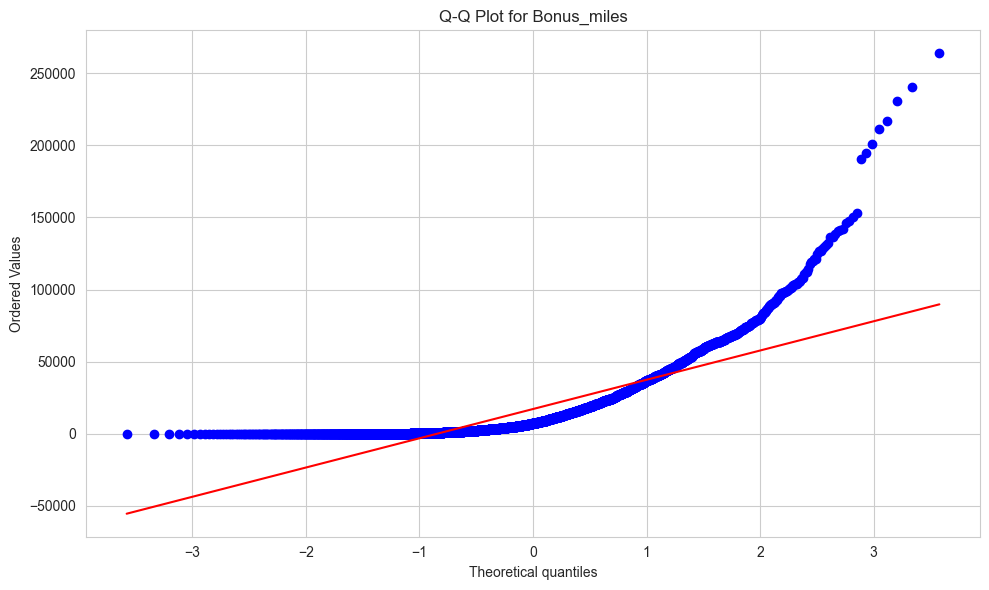

Shapiro-Wilk Test for Bonus_trans:
p-value: 0.0000
Bonus_trans does not appear to be normally distributed (reject H0)



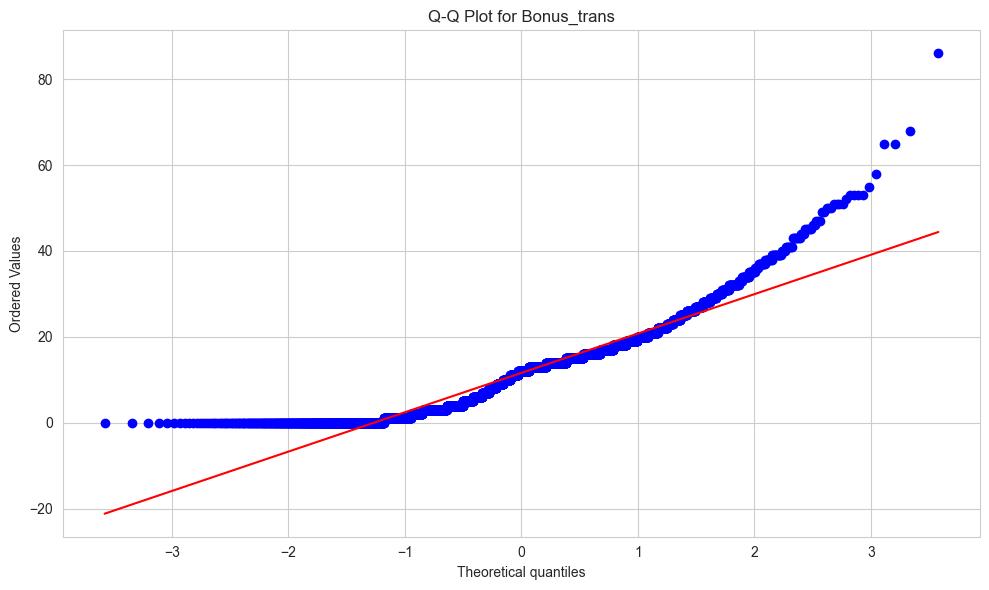

Shapiro-Wilk Test for Flight_miles_12mo:
p-value: 0.0000
Flight_miles_12mo does not appear to be normally distributed (reject H0)



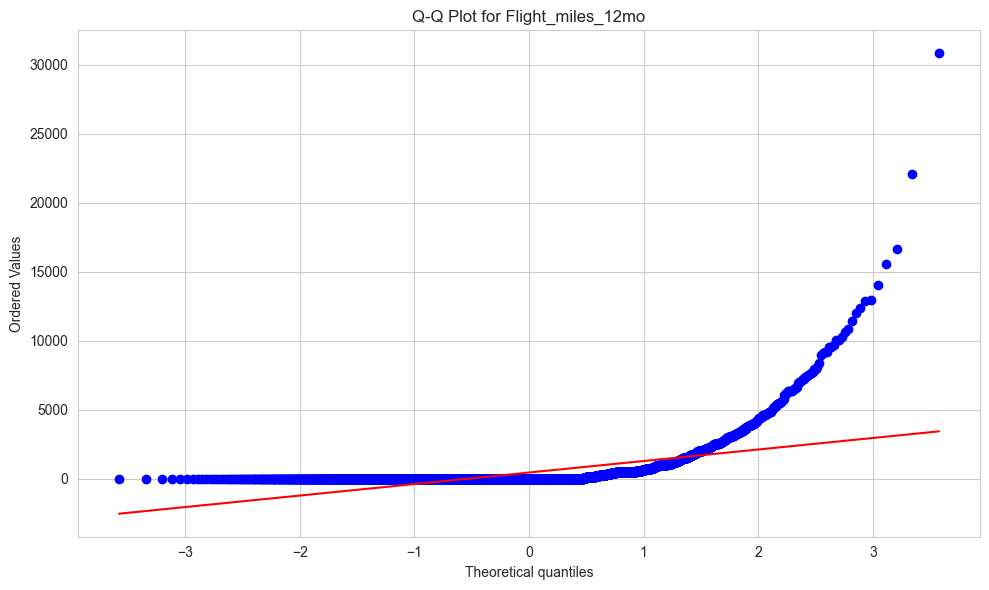

Shapiro-Wilk Test for Flight_trans_12:
p-value: 0.0000
Flight_trans_12 does not appear to be normally distributed (reject H0)



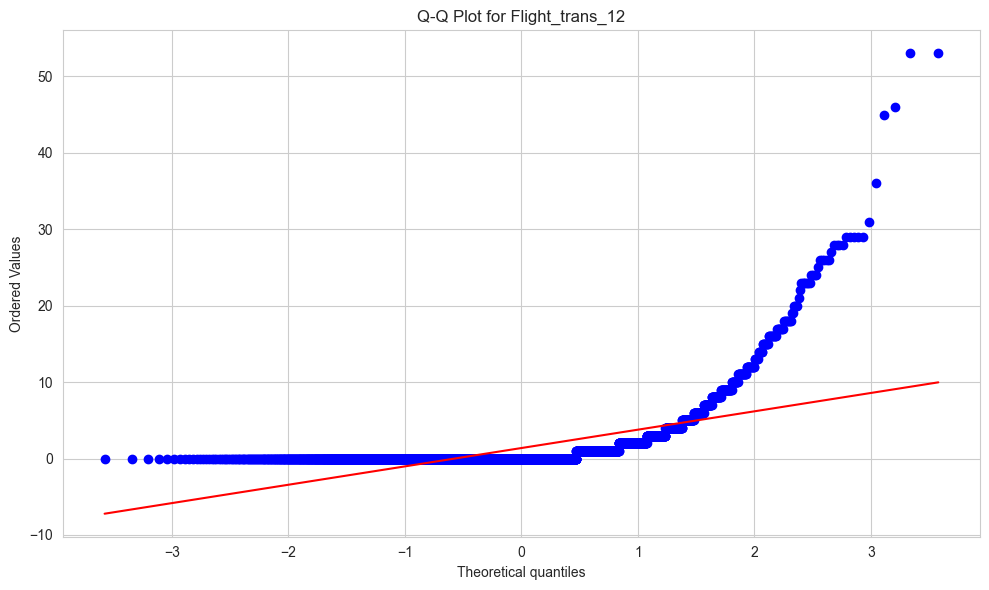

Shapiro-Wilk Test for Days_since_enroll:
p-value: 0.0000
Days_since_enroll does not appear to be normally distributed (reject H0)



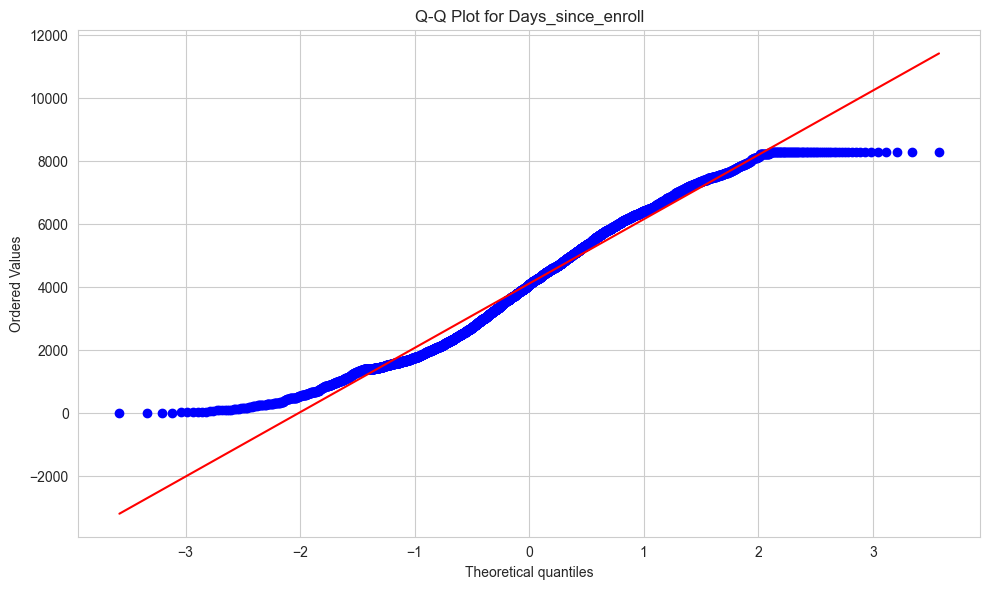

Shapiro-Wilk Test for Award?:
p-value: 0.0000
Award? does not appear to be normally distributed (reject H0)



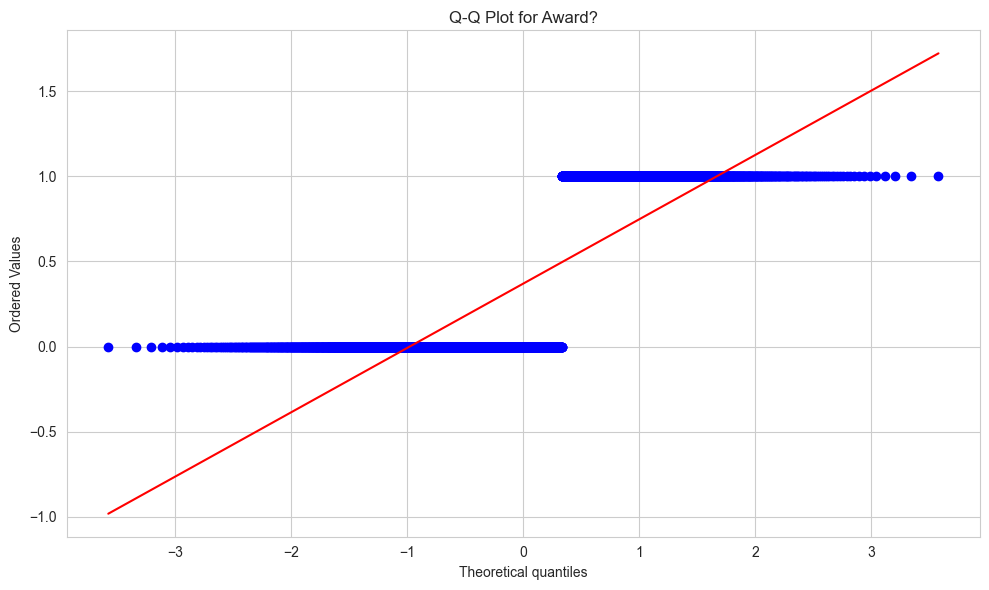


FEATURE ENGINEERING INSIGHTS

Skewness of Numerical Features:
ID#                  -0.003343
Balance               5.004187
Qual_miles            7.512395
cc1_miles             0.857569
cc2_miles            11.210459
cc3_miles            17.195532
Bonus_miles           2.842093
Bonus_trans           1.157362
Flight_miles_12mo     7.451666
Flight_trans_12       5.490461
Days_since_enroll     0.120174
Award?                0.537200
dtype: float64

Kurtosis of Numerical Features:
ID#                   -1.199648
Balance               44.157932
Qual_miles            67.689351
cc1_miles             -0.748508
cc2_miles            133.786489
cc3_miles            308.654728
Bonus_miles           13.630489
Bonus_trans            2.745737
Flight_miles_12mo     94.761019
Flight_trans_12       42.978152
Days_since_enroll     -0.967505
Award?                -1.712272
dtype: float64


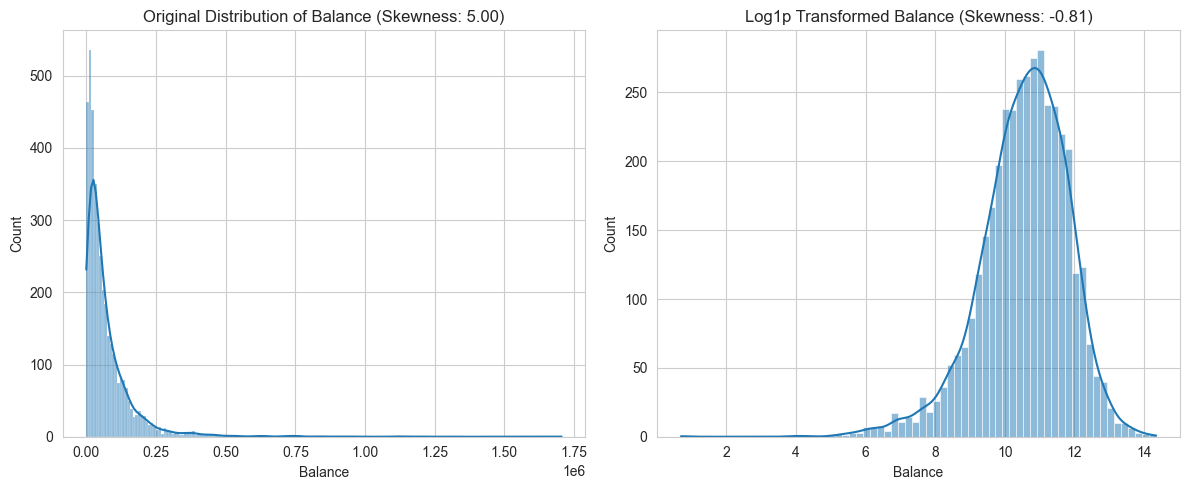

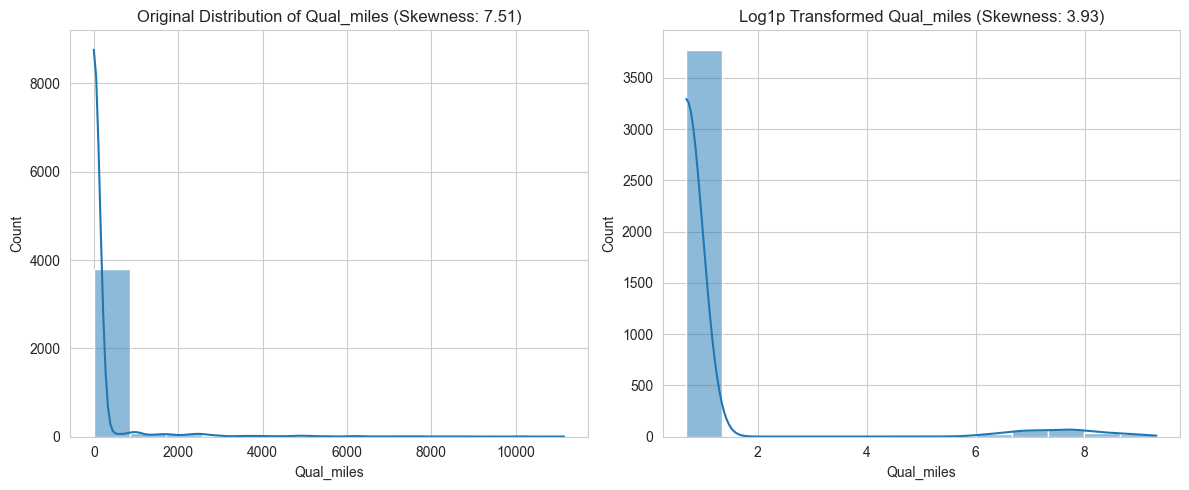

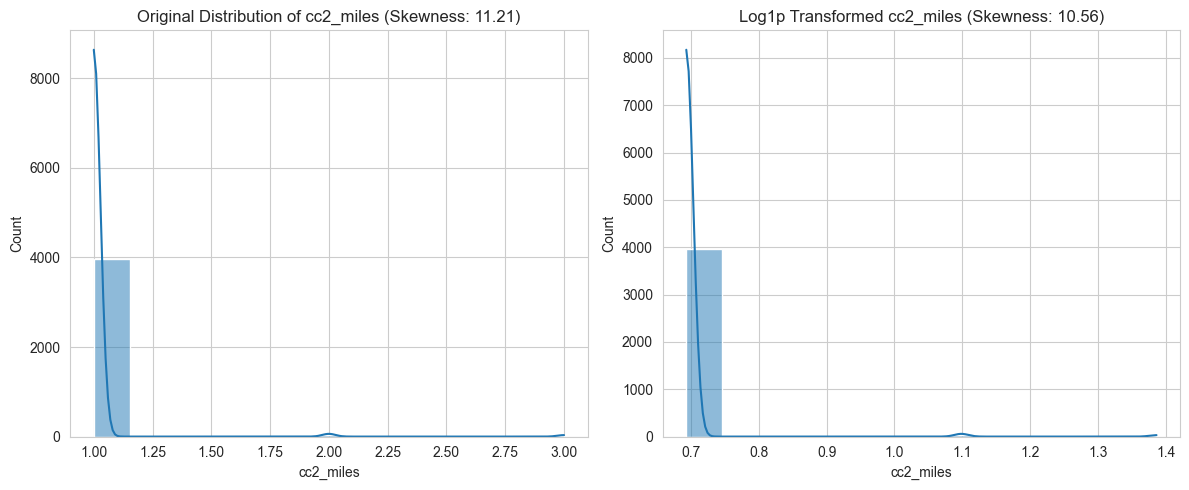

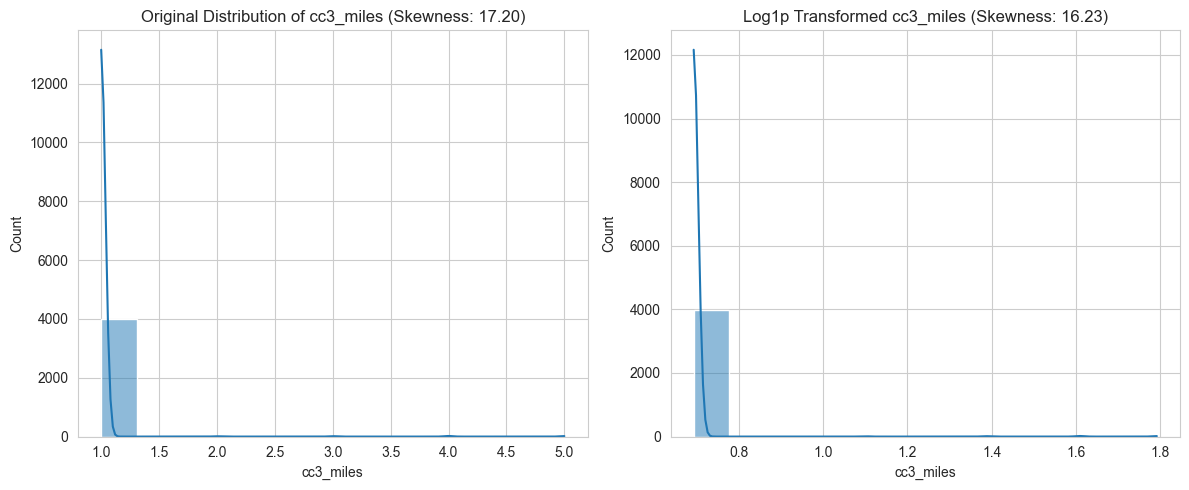

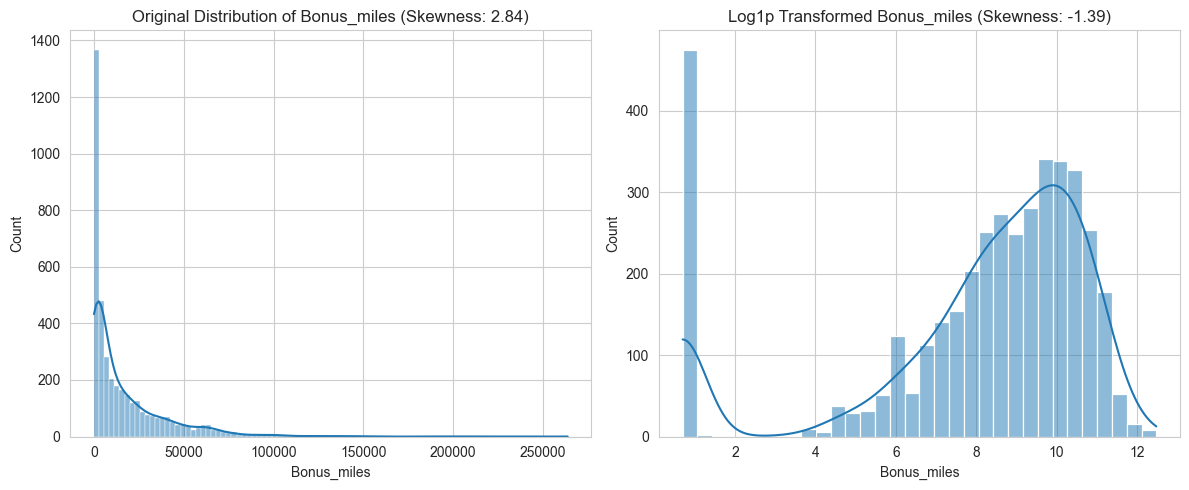

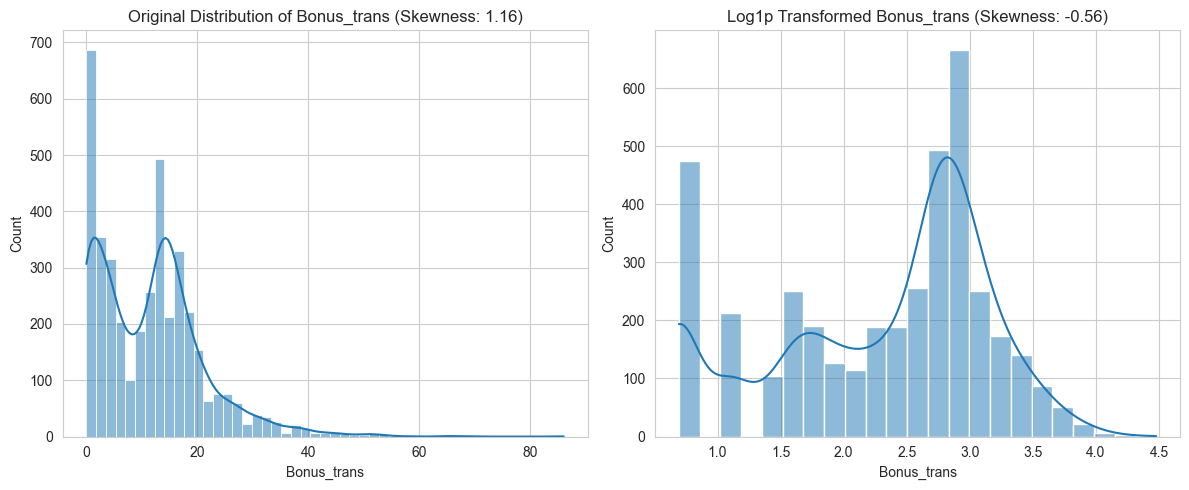

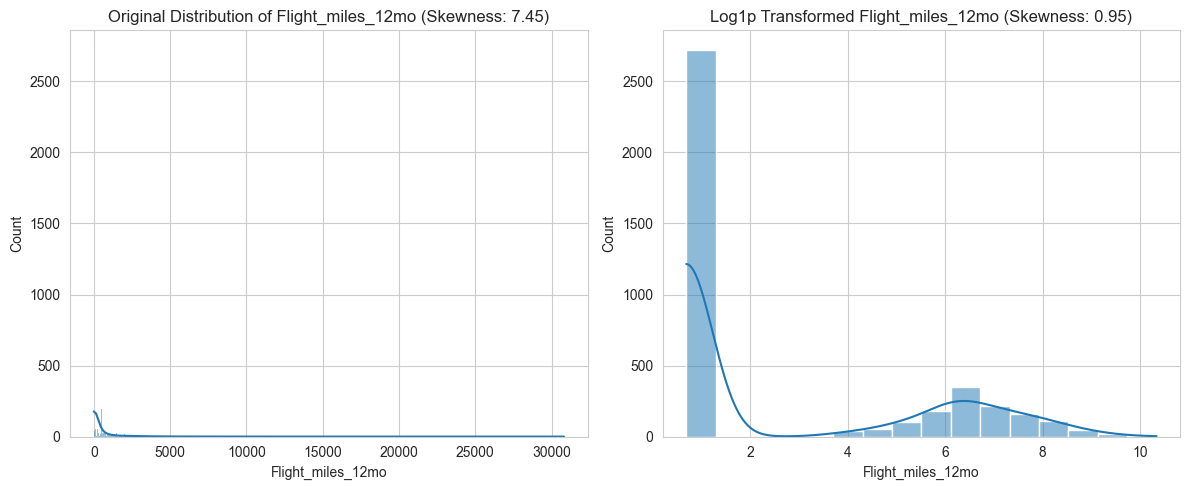

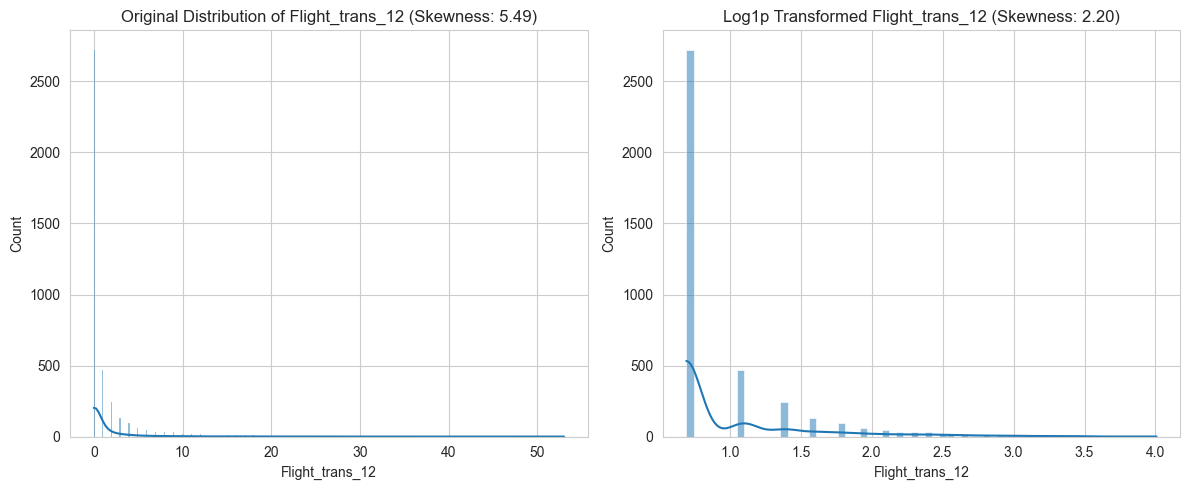


EDA COMPLETED


{'shape': (3999, 12),
 'missing': ID#                  0
 Balance              0
 Qual_miles           0
 cc1_miles            0
 cc2_miles            0
 cc3_miles            0
 Bonus_miles          0
 Bonus_trans          0
 Flight_miles_12mo    0
 Flight_trans_12      0
 Days_since_enroll    0
 Award?               0
 dtype: int64,
 'duplicates': 0,
 'numerical_columns': ['ID#',
  'Balance',
  'Qual_miles',
  'cc1_miles',
  'cc2_miles',
  'cc3_miles',
  'Bonus_miles',
  'Bonus_trans',
  'Flight_miles_12mo',
  'Flight_trans_12',
  'Days_since_enroll',
  'Award?'],
 'categorical_columns': []}

In [6]:
EDA(data)

In [7]:
#Handling skeweness using Yeo - Johnson Transformation as ther are negative values
transformer = PowerTransformer(method='yeo-johnson', standardize= True)
numerical_cols = data.select_dtypes(include=[np.number]).columns
transformed_data = transformer.fit_transform(data[numerical_cols])
transformed_df = pd.DataFrame(transformed_data, columns=numerical_cols)

# Replace original numerical columns with transformed values
data[numerical_cols] = transformed_df
# Print results
print("Original Data (with non-numerical columns unchanged):\n", data)


Original Data (with non-numerical columns unchanged):
            ID#   Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
0    -2.178423 -0.346816   -0.244743  -0.844766        0.0        0.0   
1    -2.172818 -0.633084   -0.244743  -0.844766        0.0        0.0   
2    -2.167737 -0.038549   -0.244743  -0.844766        0.0        0.0   
3    -2.163015 -0.821989   -0.244743  -0.844766        0.0        0.0   
4    -2.158560  0.723596   -0.244743   1.343165        0.0        0.0   
...        ...       ...         ...        ...        ...        ...   
3994  1.551145 -0.662730   -0.244743  -0.844766        0.0        0.0   
3995  1.551808  0.340486   -0.244743  -0.844766        0.0        0.0   
3996  1.552471  0.460388   -0.244743   1.058591        0.0        0.0   
3997  1.553134  0.200904   -0.244743  -0.844766        0.0        0.0   
3998  1.553797 -1.803321   -0.244743  -0.844766        0.0        0.0   

      Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  

In [8]:
data.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-2.178423,-0.346816,-0.244743,-0.844766,0.0,0.0,-1.178402,-1.329671,-0.683308,-0.674970,1.321776,-0.766919
1,-2.172818,-0.633084,-0.244743,-0.844766,0.0,0.0,-1.132416,-1.074960,-0.683308,-0.674970,1.308873,-0.766919
2,-2.167737,-0.038549,-0.244743,-0.844766,0.0,0.0,-0.191941,-0.688822,-0.683308,-0.674970,1.335468,-0.766919
3,-2.163015,-0.821989,-0.244743,-0.844766,0.0,0.0,-0.924946,-1.329671,-0.683308,-0.674970,1.302415,-0.766919
4,-2.158560,0.723596,-0.244743,1.343165,0.0,0.0,1.169363,1.329711,1.549026,1.685925,1.295549,1.303918


BASIC DATASET INFORMATION
SHAPE: (3999, 12) 

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID#                3999 non-null   float64
 1   Balance            3999 non-null   float64
 2   Qual_miles         3999 non-null   float64
 3   cc1_miles          3999 non-null   float64
 4   cc2_miles          3999 non-null   float64
 5   cc3_miles          3999 non-null   float64
 6   Bonus_miles        3999 non-null   float64
 7   Bonus_trans        3999 non-null   float64
 8   Flight_miles_12mo  3999 non-null   float64
 9   Flight_trans_12    3999 non-null   float64
 10  Days_since_enroll  3999 non-null   float64
 11  Award?             3999 non-null   float64
dtypes: float64(12)
memory usage: 375.0 KB
None 

STATISTICAL SUMMARY:
                ID#       Balance    Qual_miles     cc1_miles     cc2_miles  \
count  3.999000e+03

<Figure size 1200x600 with 0 Axes>

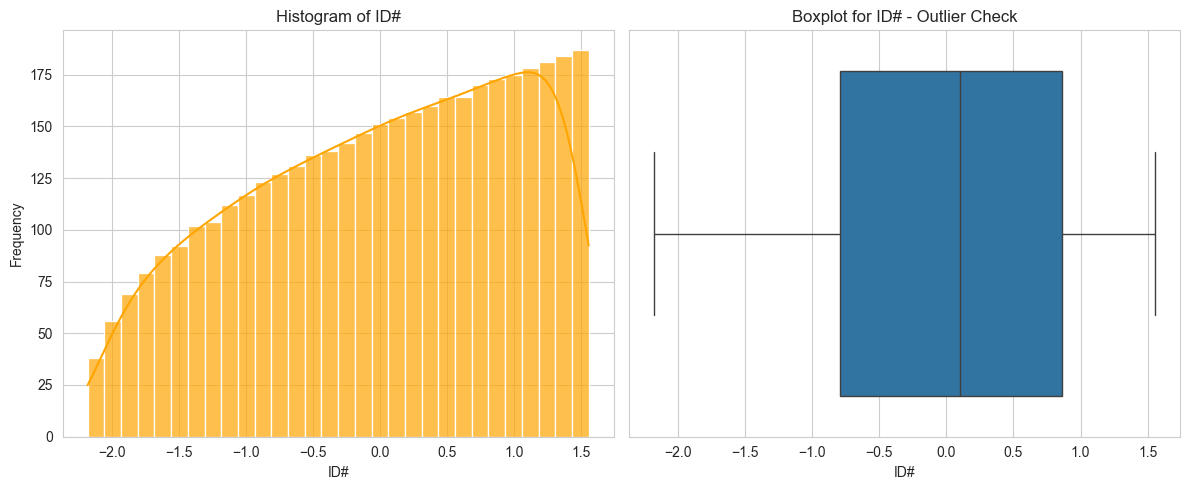

Outliers in ID#: 0 (0.00%)


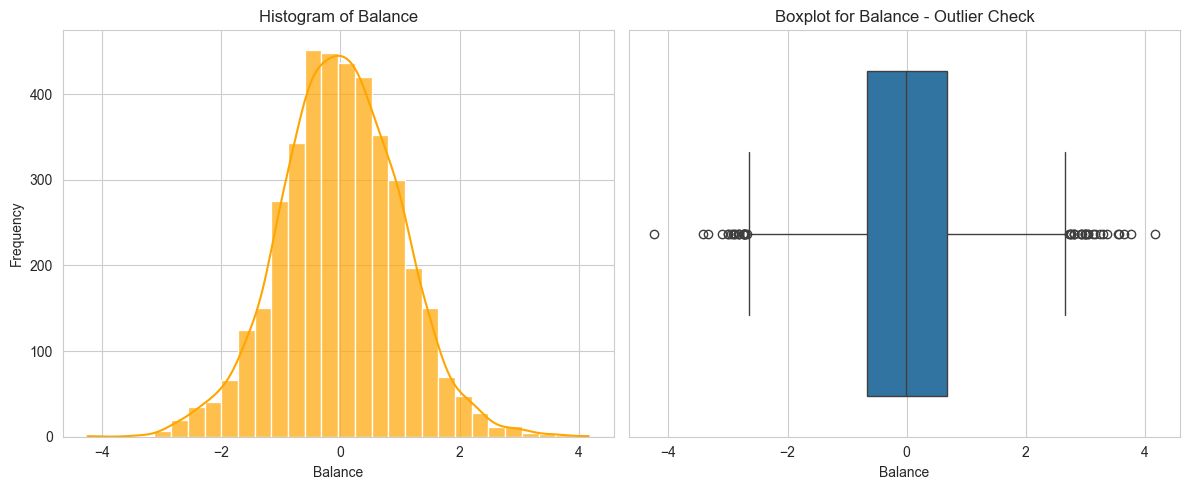

Outliers in Balance: 47 (1.18%)


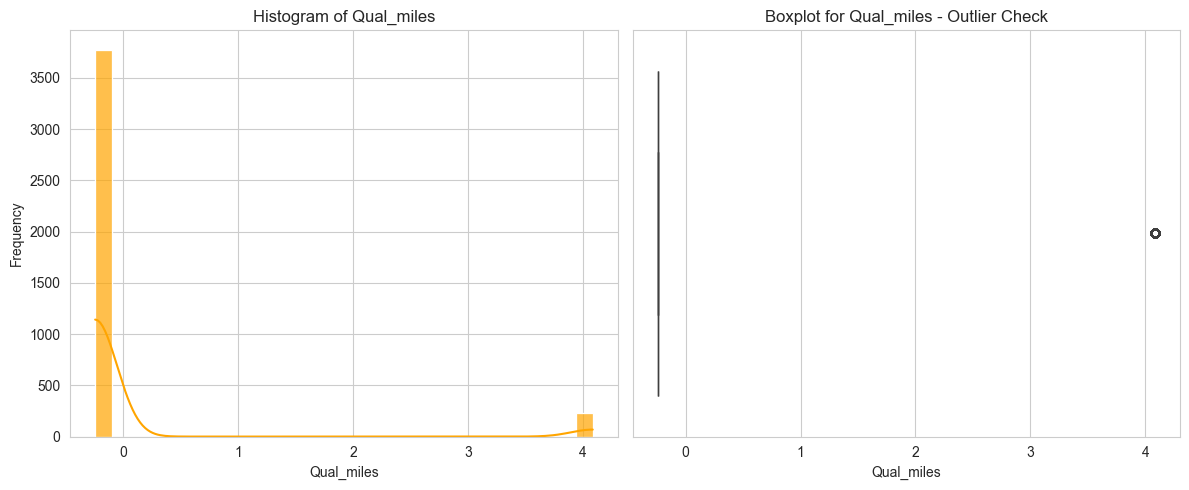

Outliers in Qual_miles: 226 (5.65%)


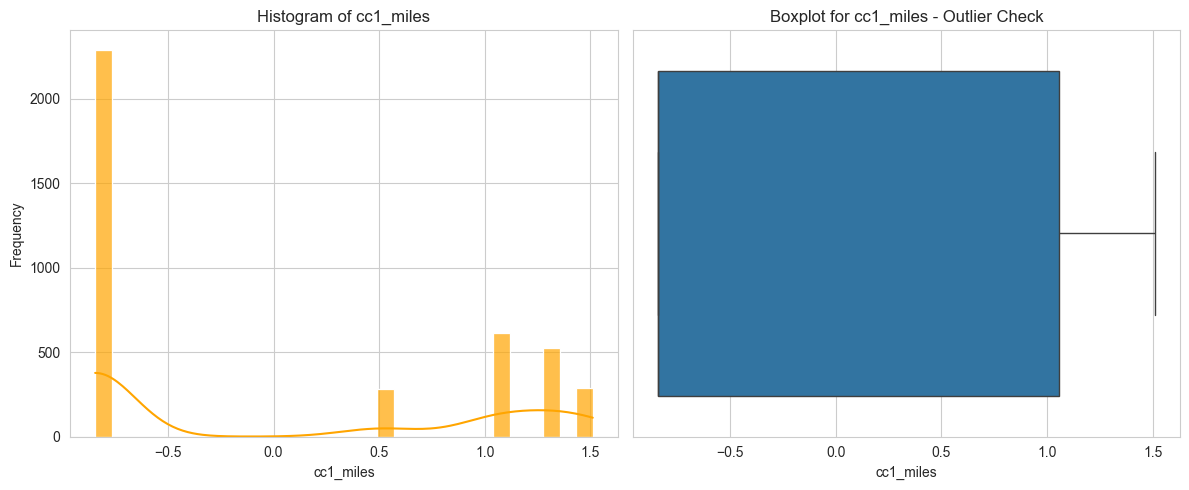

Outliers in cc1_miles: 0 (0.00%)


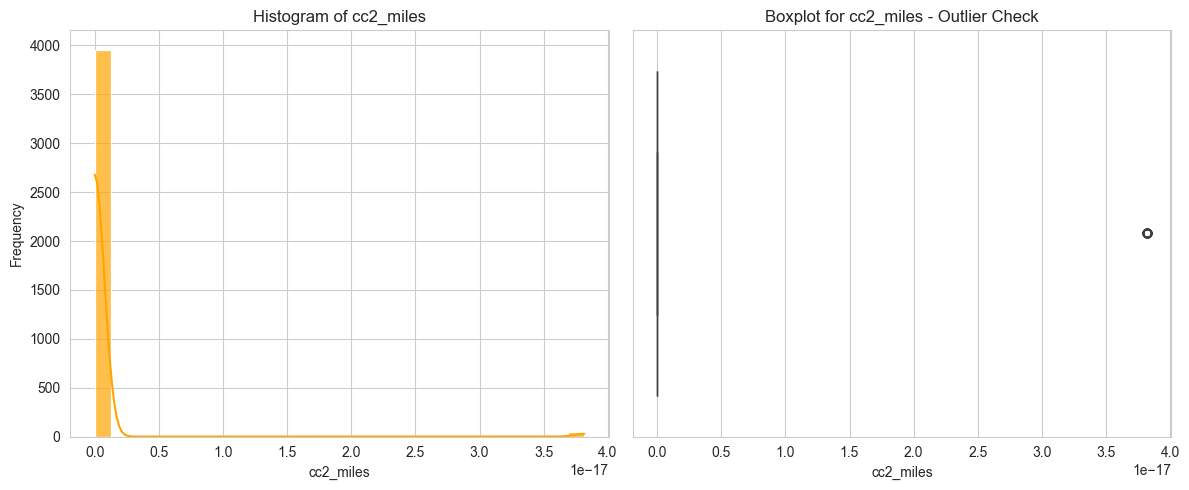

Outliers in cc2_miles: 43 (1.08%)


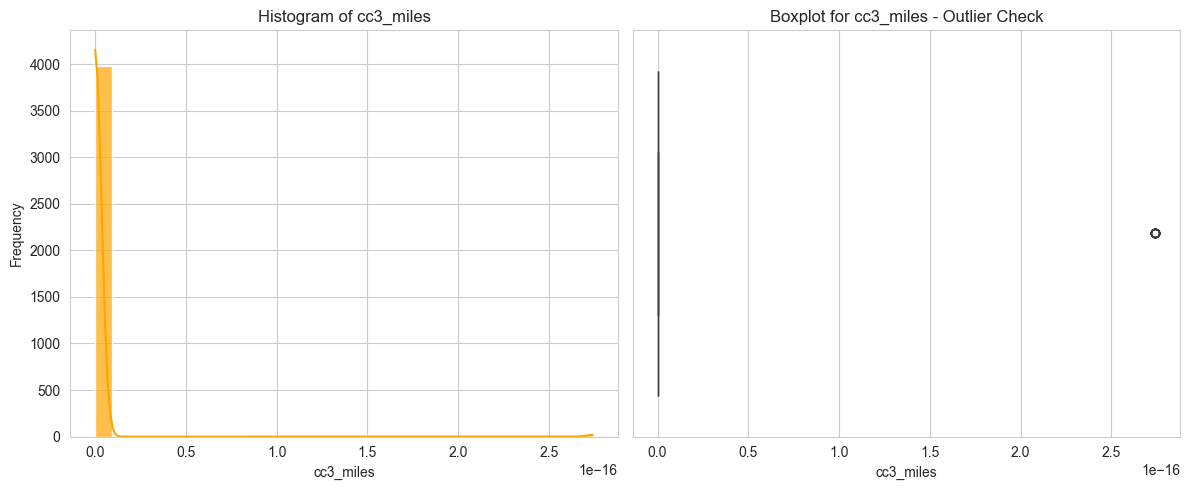

Outliers in cc3_miles: 18 (0.45%)


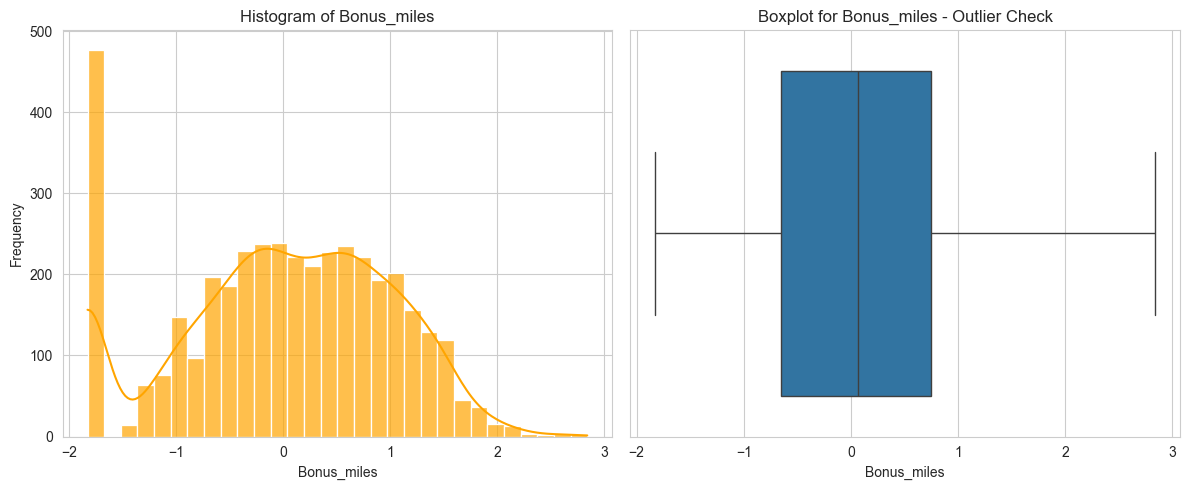

Outliers in Bonus_miles: 0 (0.00%)


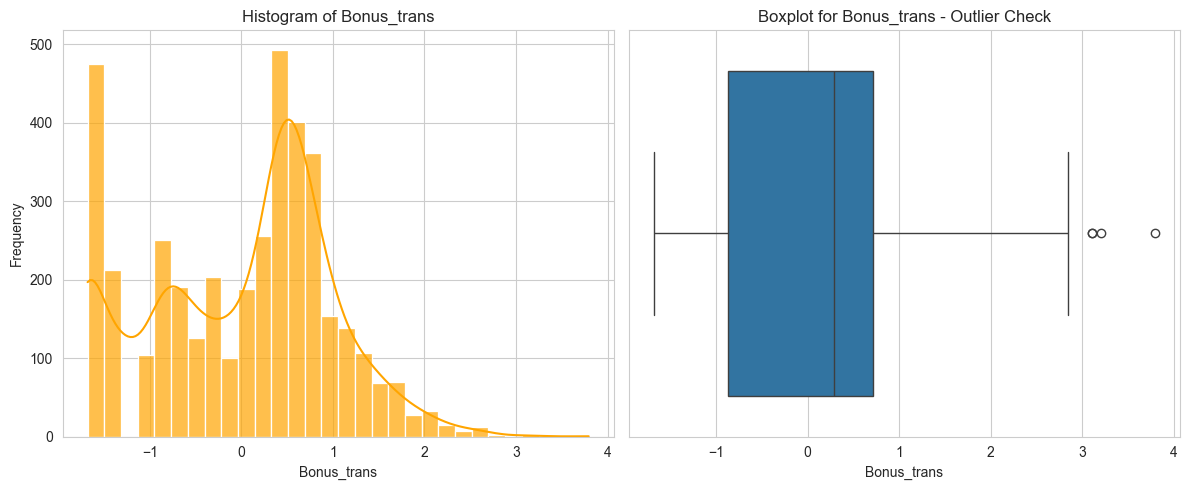

Outliers in Bonus_trans: 4 (0.10%)


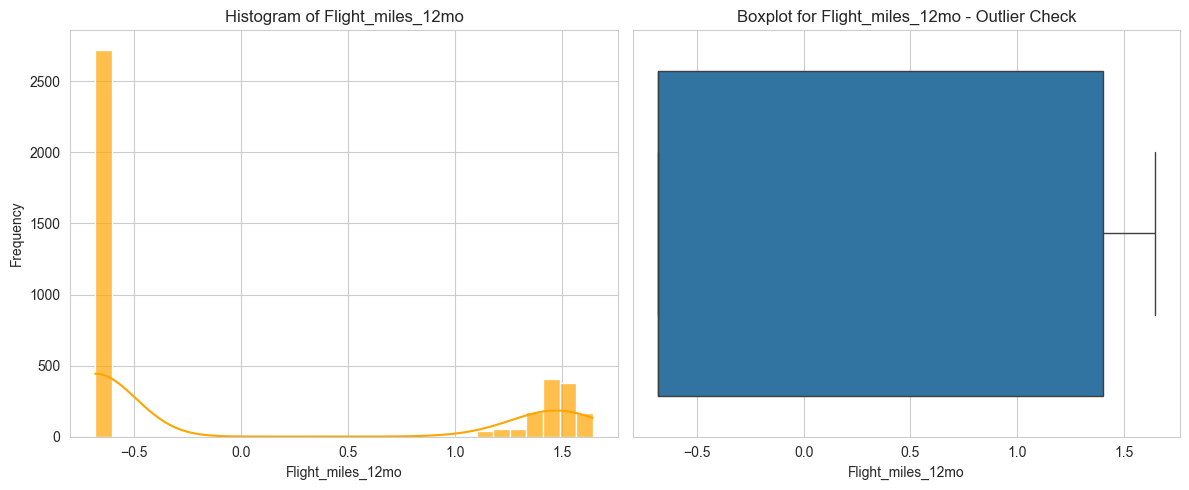

Outliers in Flight_miles_12mo: 0 (0.00%)


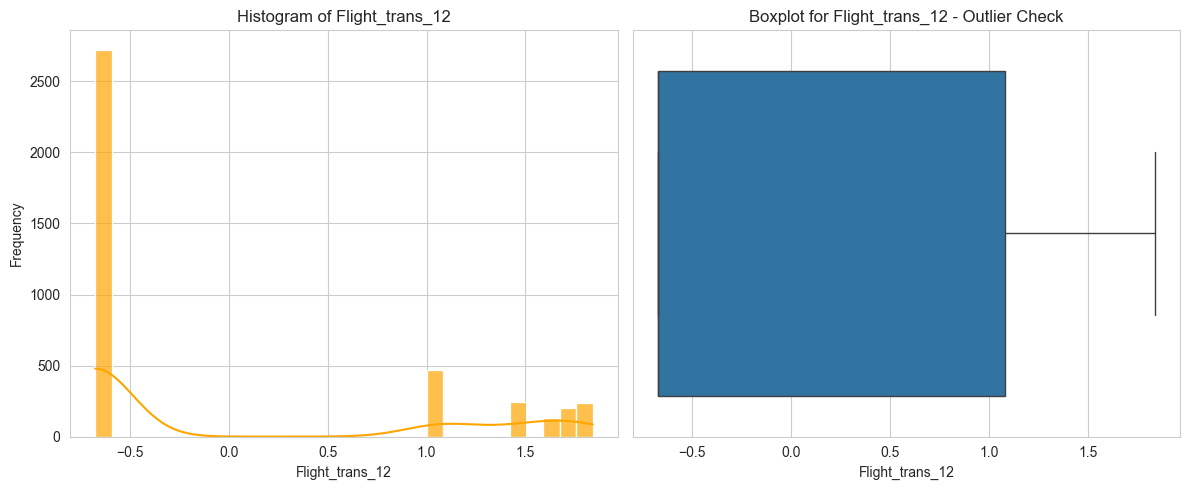

Outliers in Flight_trans_12: 0 (0.00%)


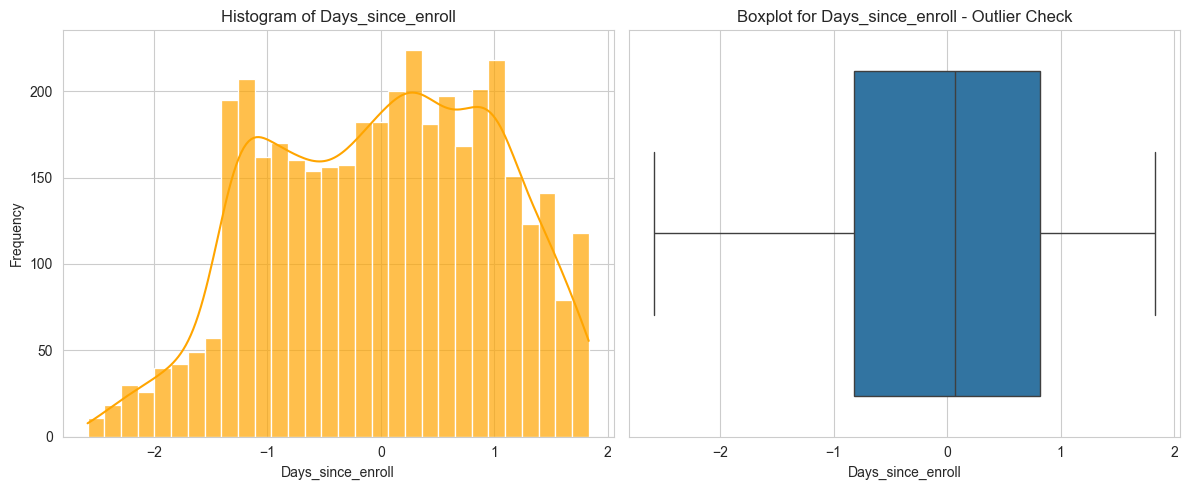

Outliers in Days_since_enroll: 0 (0.00%)


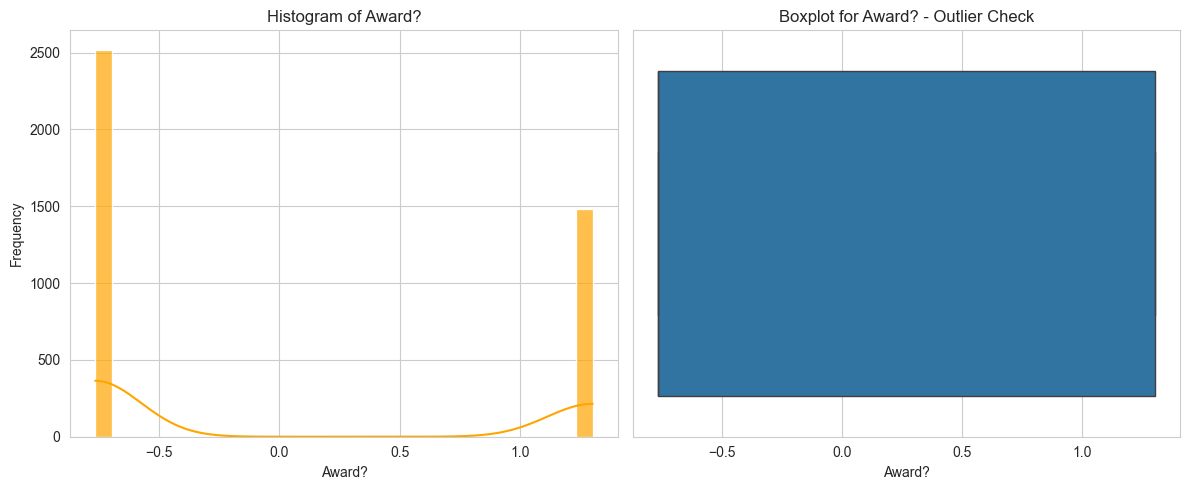

Outliers in Award?: 0 (0.00%)

Correlation Analysis:


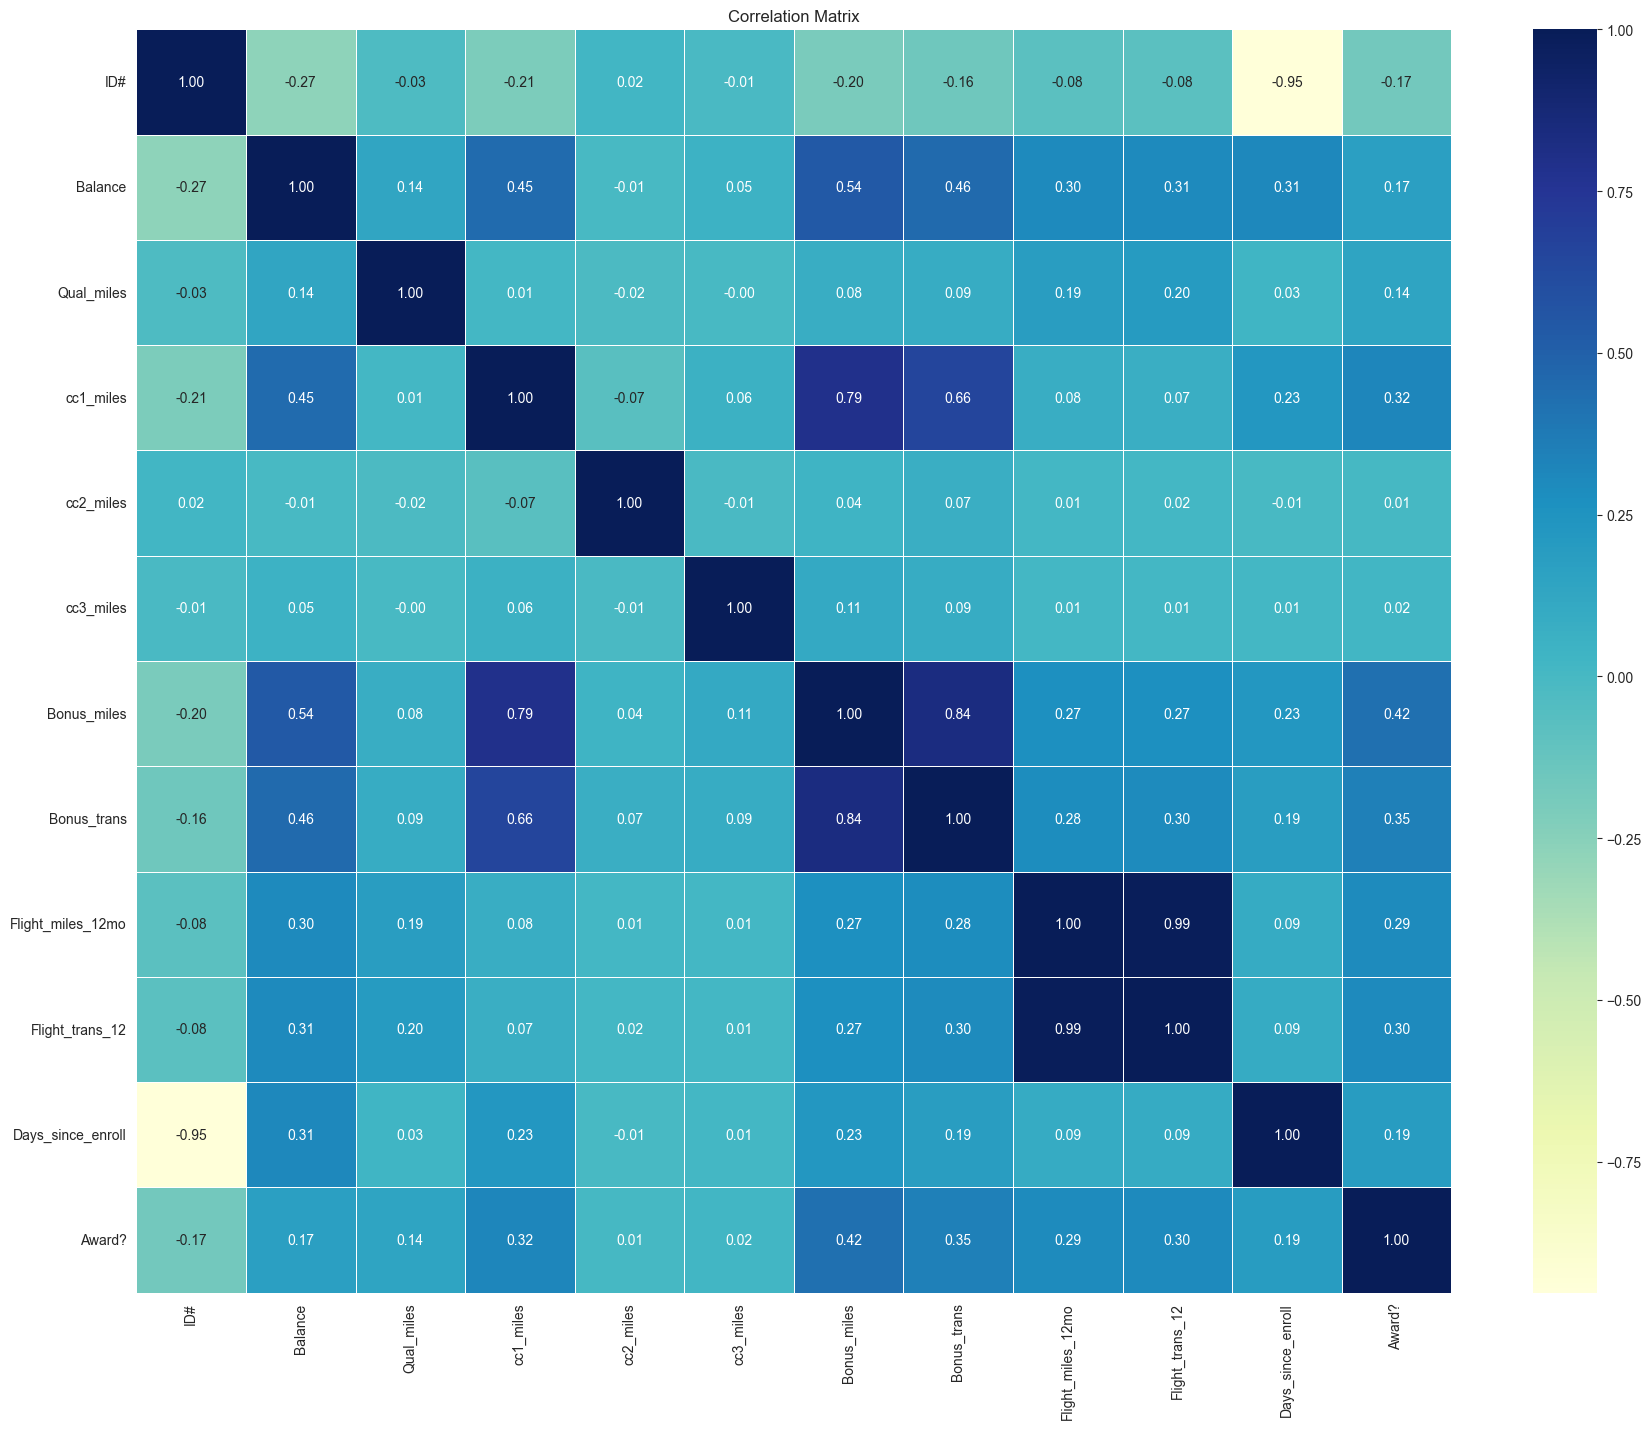


Highest Correlations:
Flight_trans_12    Flight_miles_12mo    0.991291
Flight_miles_12mo  Flight_trans_12      0.991291
Bonus_trans        Bonus_miles          0.838148
Bonus_miles        Bonus_trans          0.838148
cc1_miles          Bonus_miles          0.792272
Bonus_miles        cc1_miles            0.792272
cc1_miles          Bonus_trans          0.655915
Bonus_trans        cc1_miles            0.655915
Bonus_miles        Balance              0.538625
Balance            Bonus_miles          0.538625
dtype: float64

BIVARIATE ANALYSIS

Pairplot of Numerical Features:


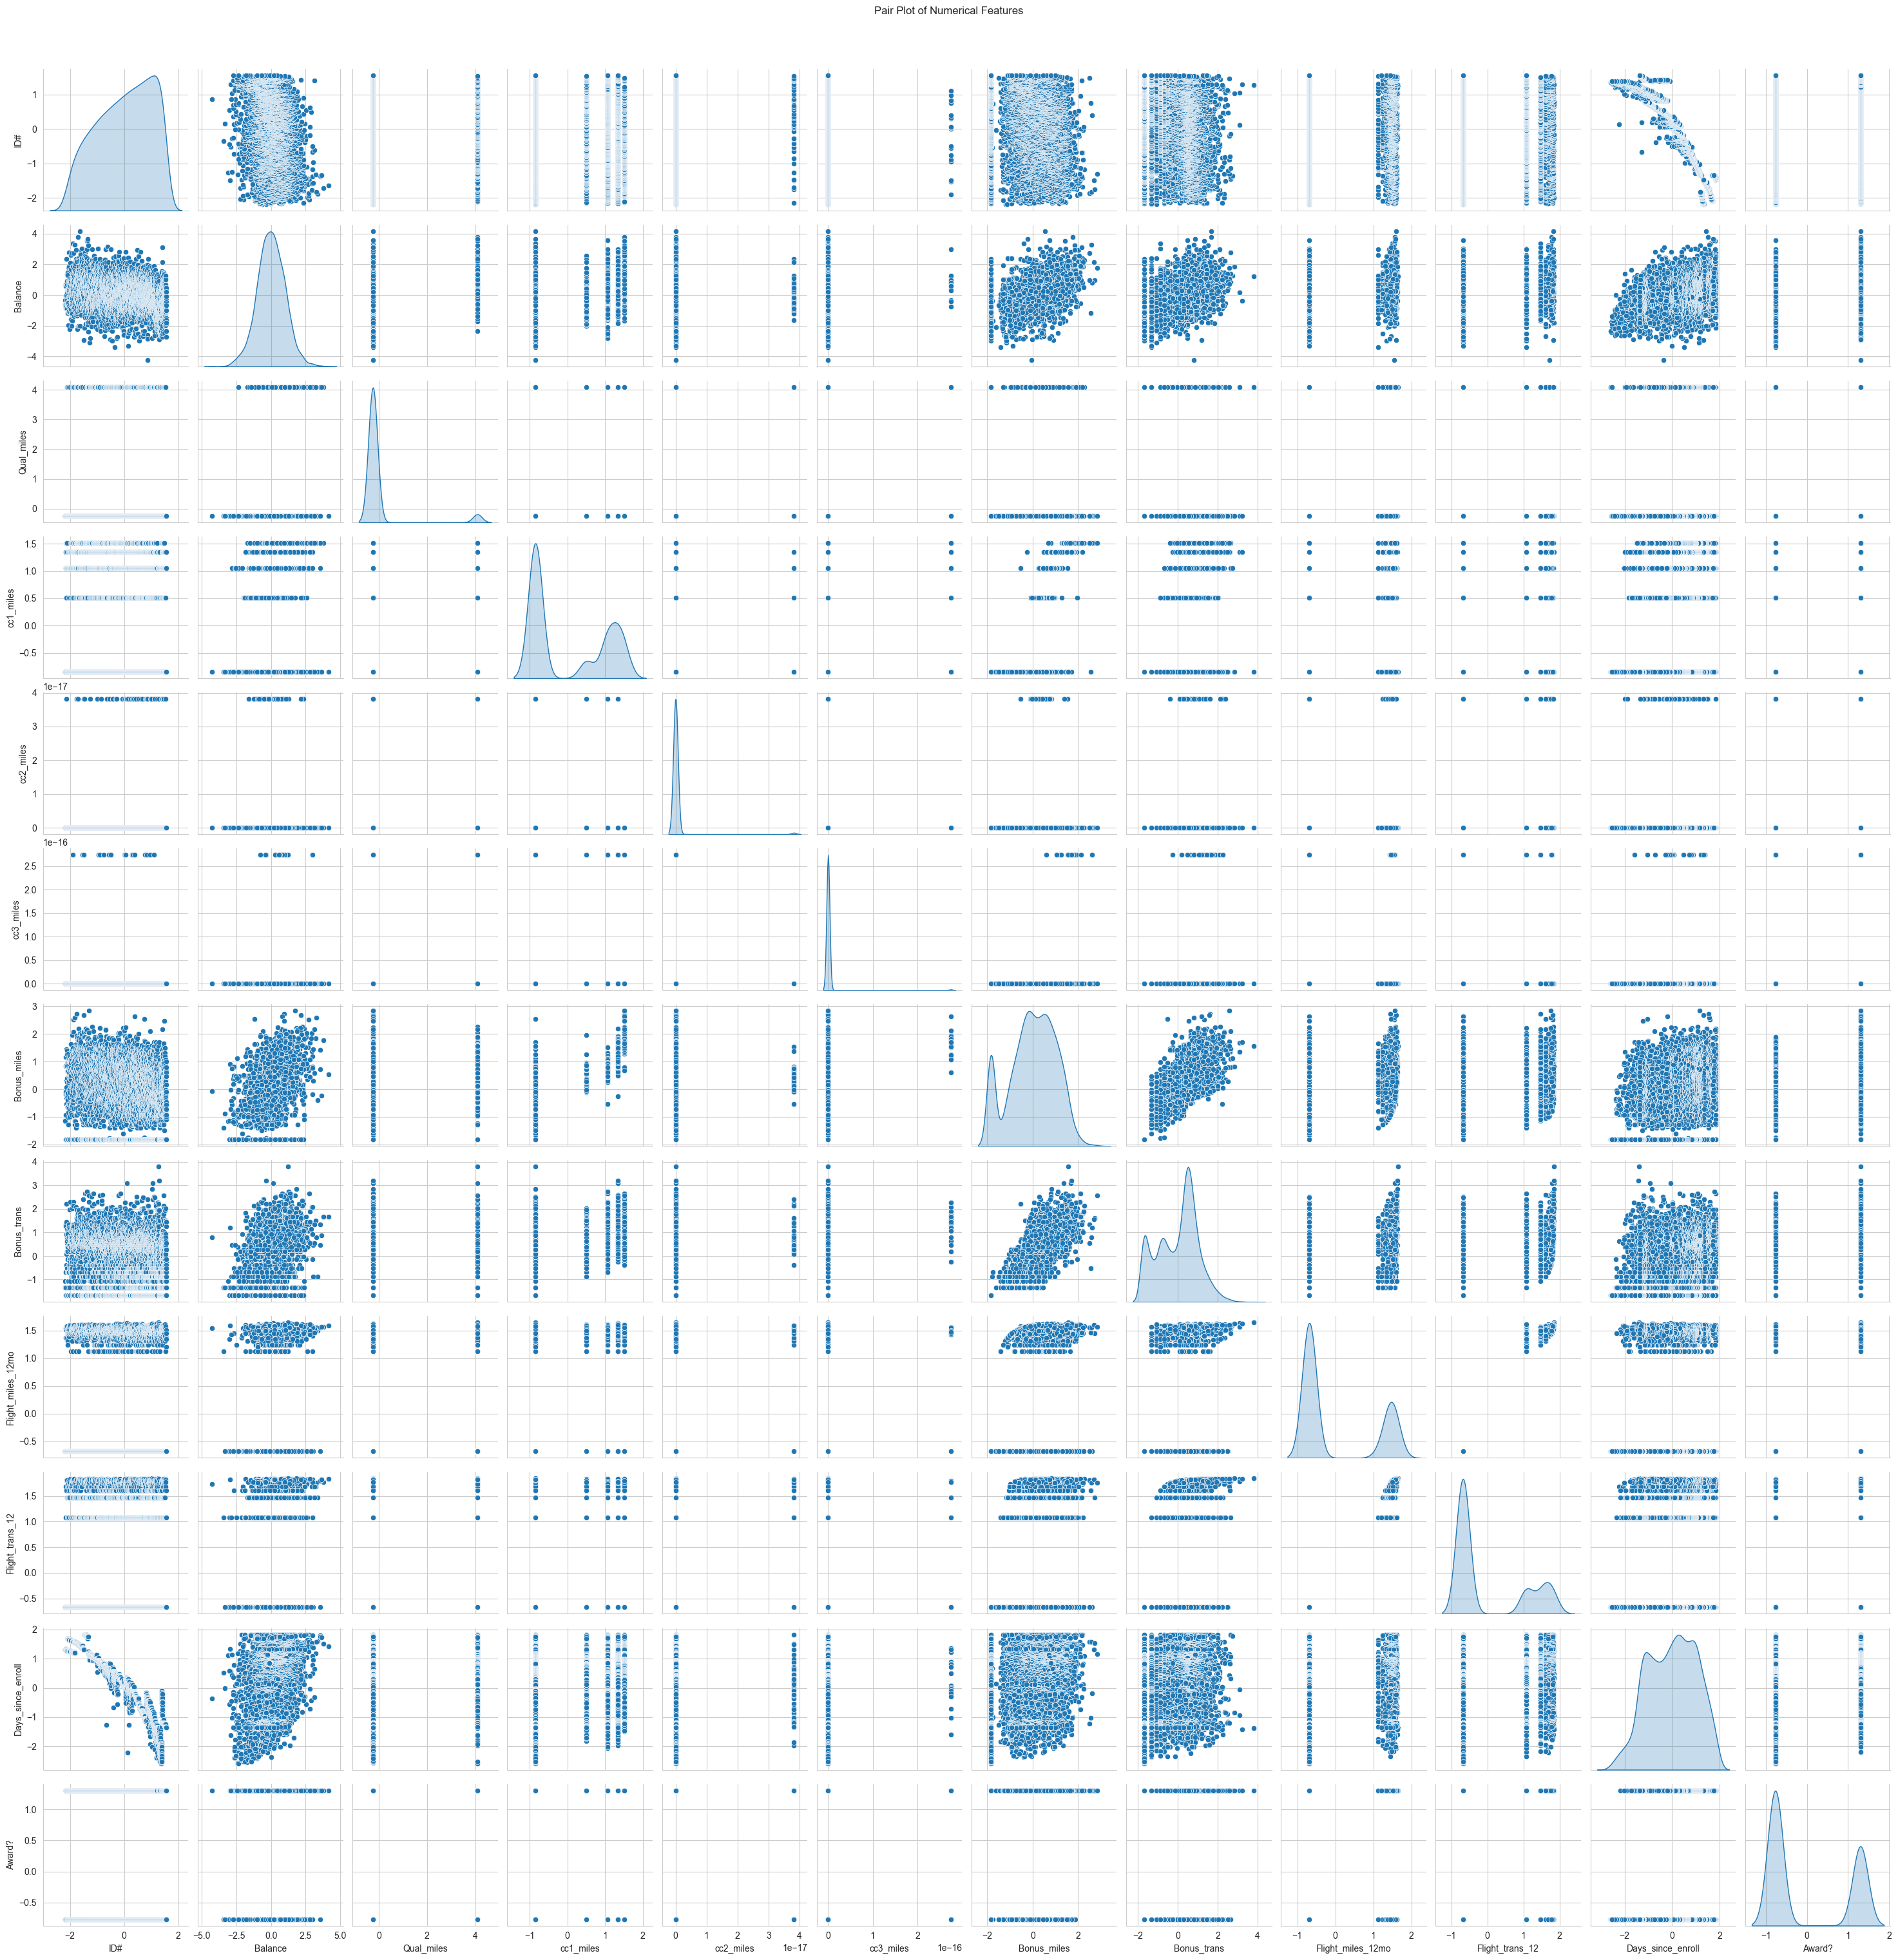


DISTRIBUTION ANALYSIS
Shapiro-Wilk Test for ID#:
p-value: 0.0000
ID# does not appear to be normally distributed (reject H0)



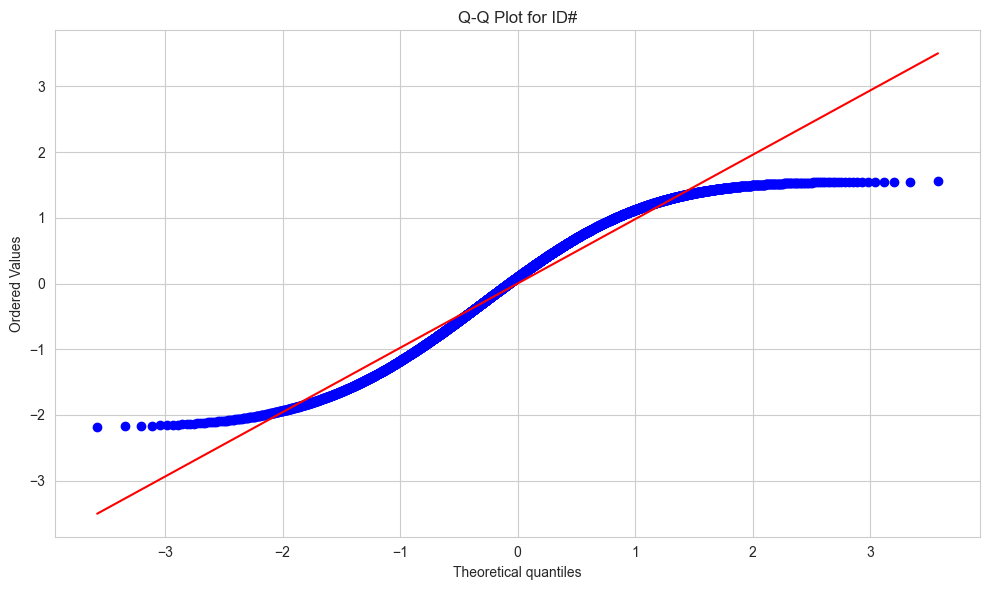

Shapiro-Wilk Test for Balance:
p-value: 0.0002
Balance does not appear to be normally distributed (reject H0)



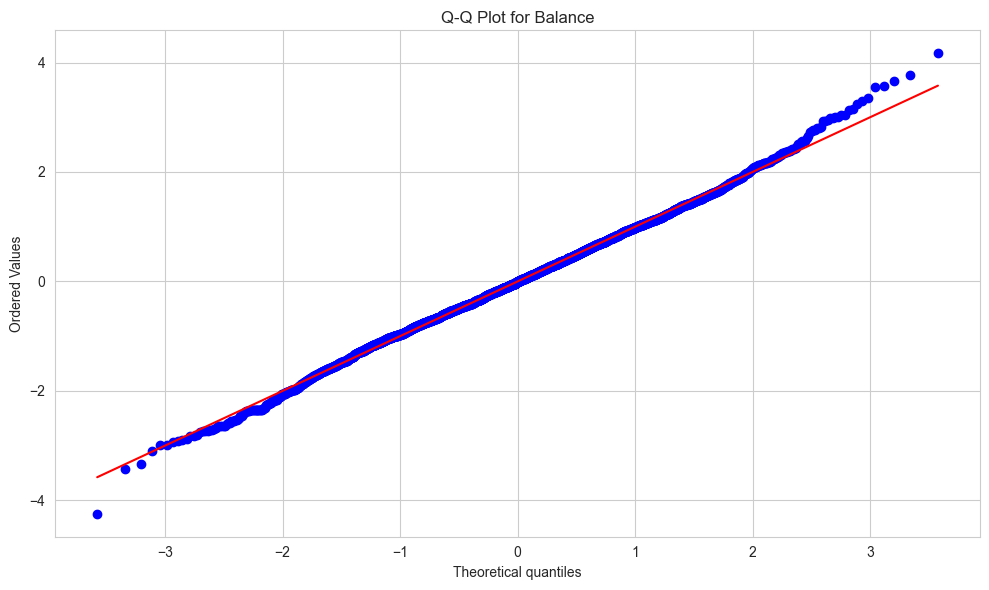

Shapiro-Wilk Test for Qual_miles:
p-value: 0.0000
Qual_miles does not appear to be normally distributed (reject H0)



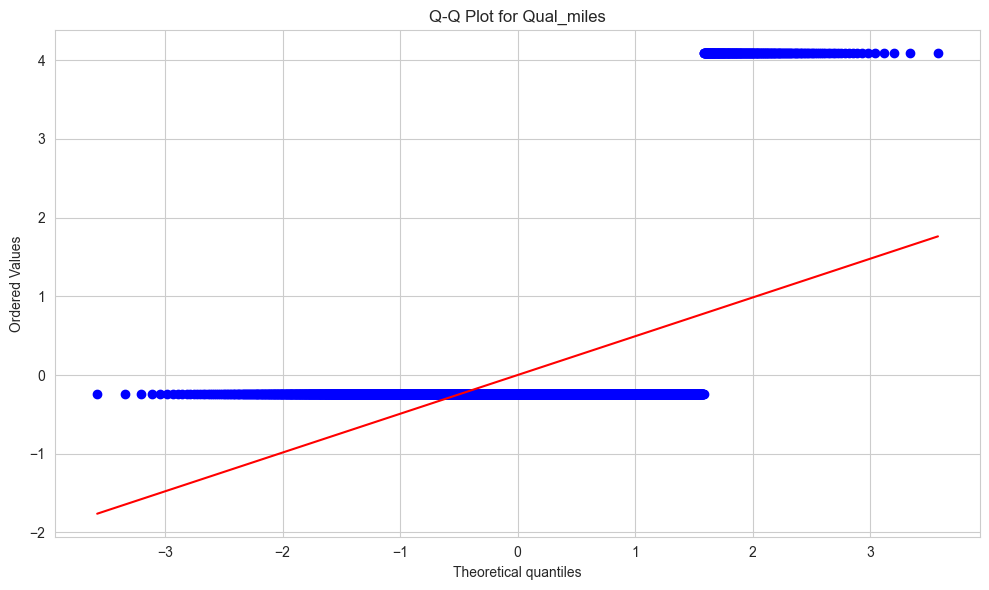

Shapiro-Wilk Test for cc1_miles:
p-value: 0.0000
cc1_miles does not appear to be normally distributed (reject H0)



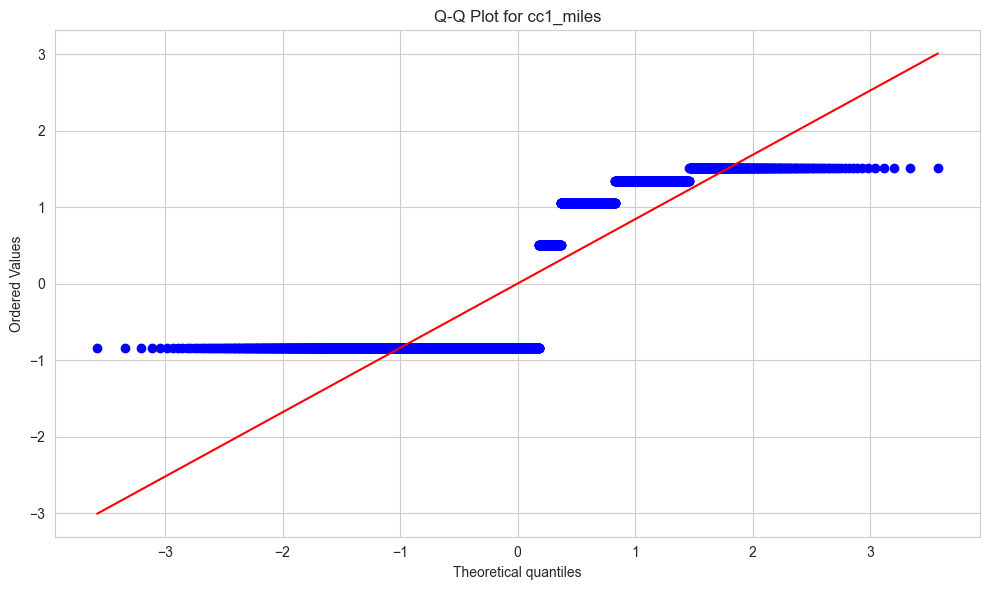

Shapiro-Wilk Test for cc2_miles:
p-value: 0.0000
cc2_miles does not appear to be normally distributed (reject H0)



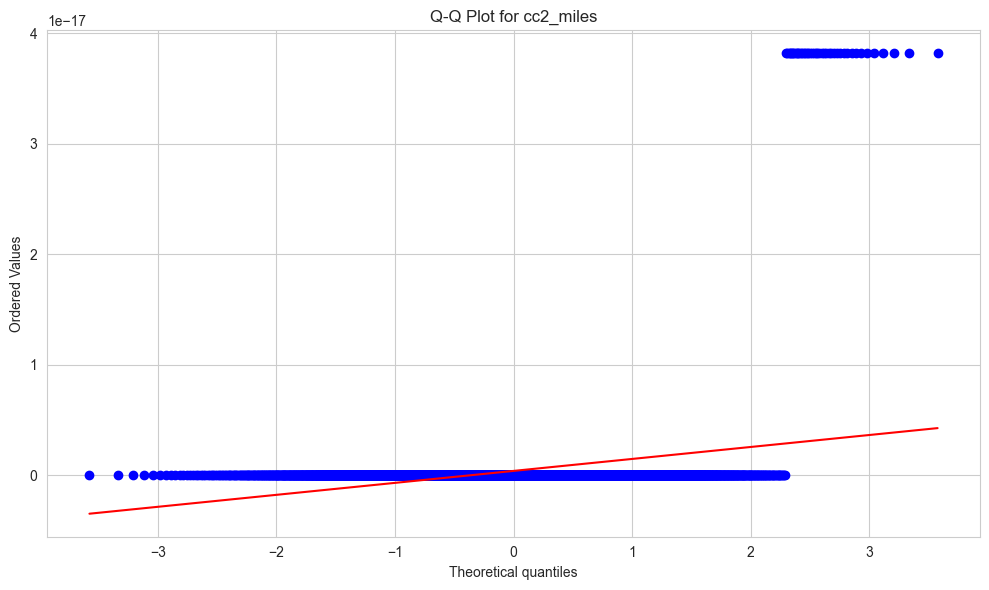

Shapiro-Wilk Test for cc3_miles:
p-value: 0.0000
cc3_miles does not appear to be normally distributed (reject H0)



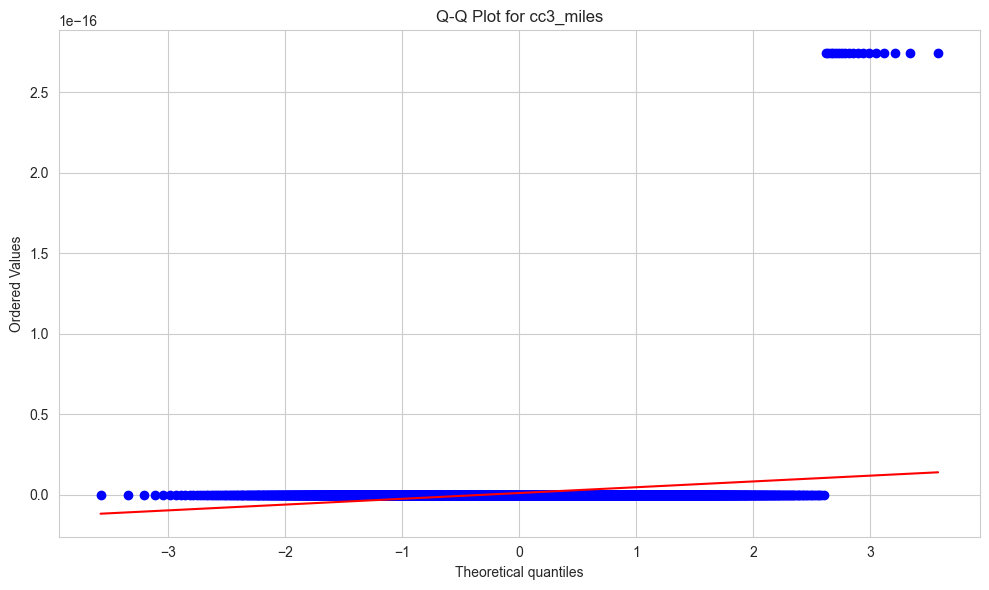

Shapiro-Wilk Test for Bonus_miles:
p-value: 0.0000
Bonus_miles does not appear to be normally distributed (reject H0)



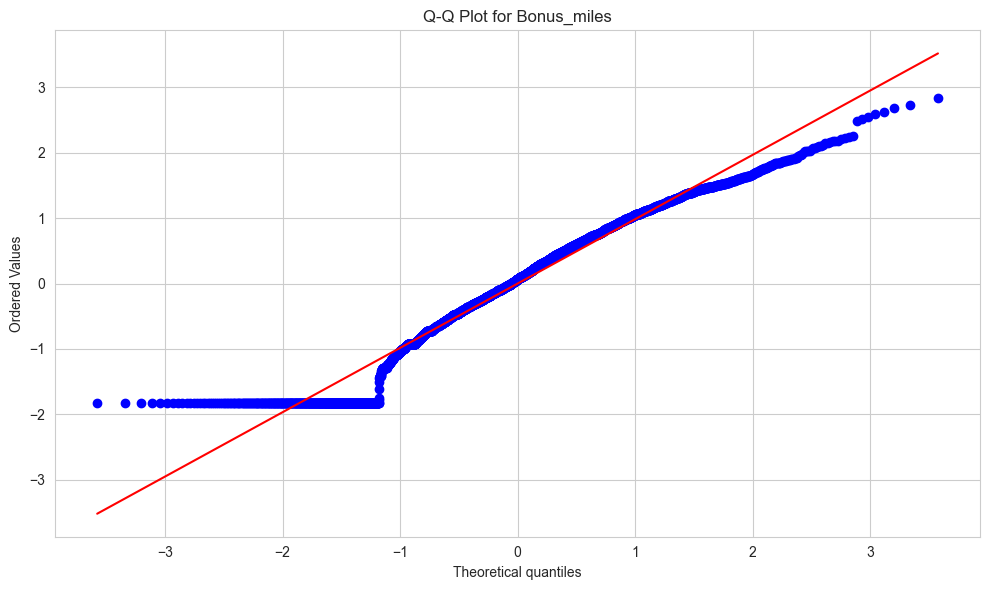

Shapiro-Wilk Test for Bonus_trans:
p-value: 0.0000
Bonus_trans does not appear to be normally distributed (reject H0)



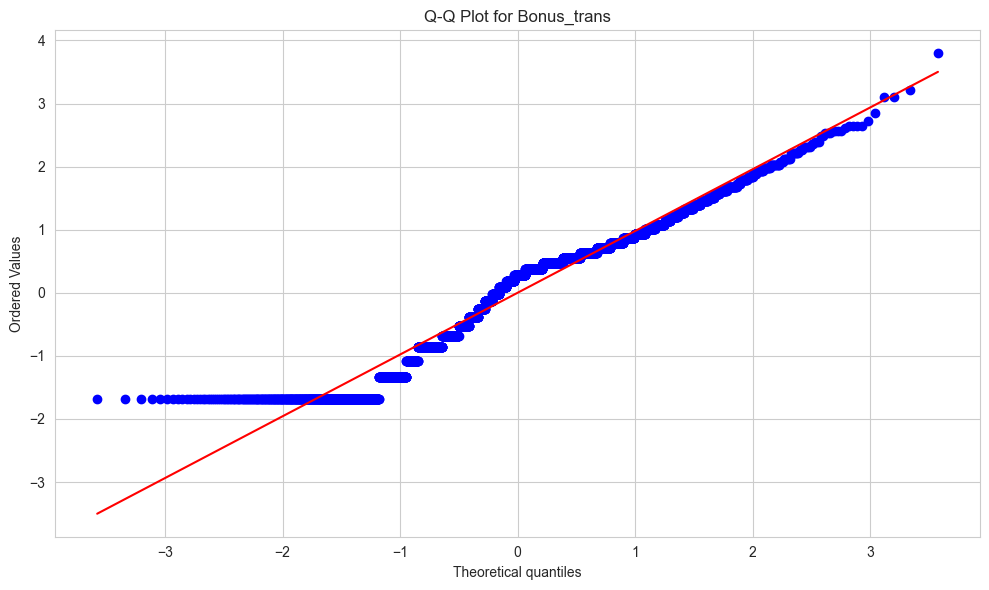

Shapiro-Wilk Test for Flight_miles_12mo:
p-value: 0.0000
Flight_miles_12mo does not appear to be normally distributed (reject H0)



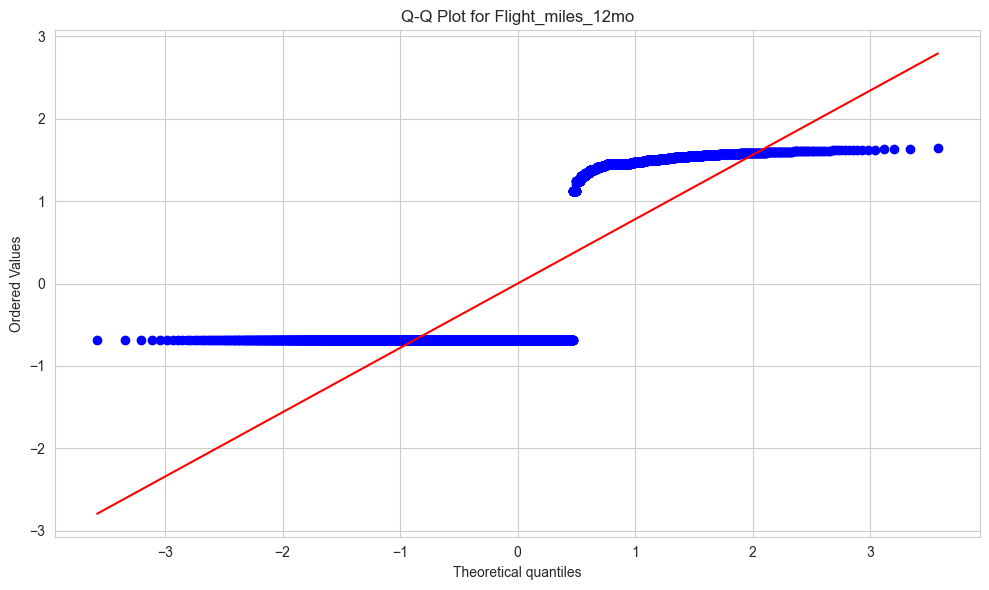

Shapiro-Wilk Test for Flight_trans_12:
p-value: 0.0000
Flight_trans_12 does not appear to be normally distributed (reject H0)



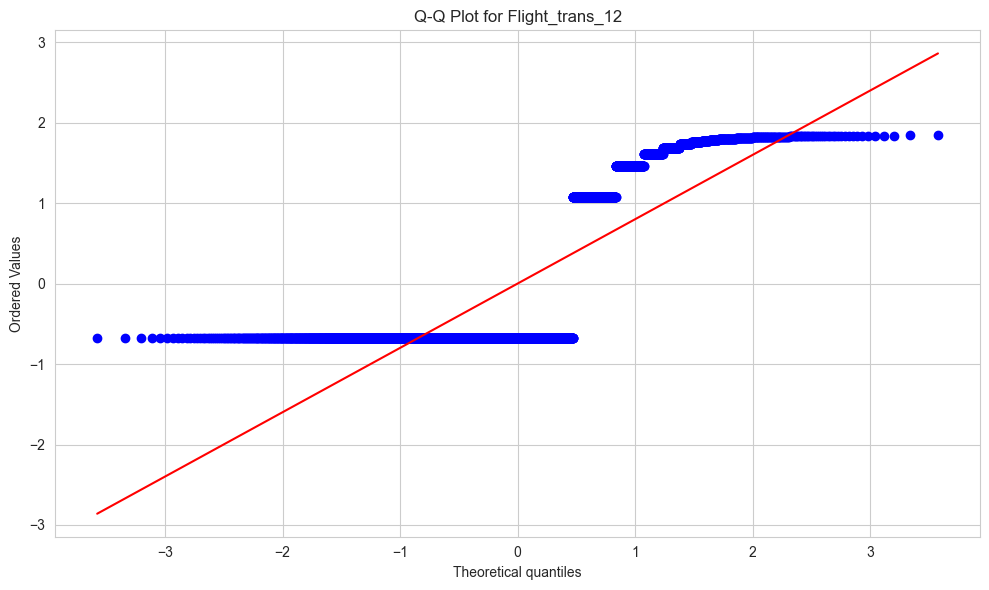

Shapiro-Wilk Test for Days_since_enroll:
p-value: 0.0000
Days_since_enroll does not appear to be normally distributed (reject H0)



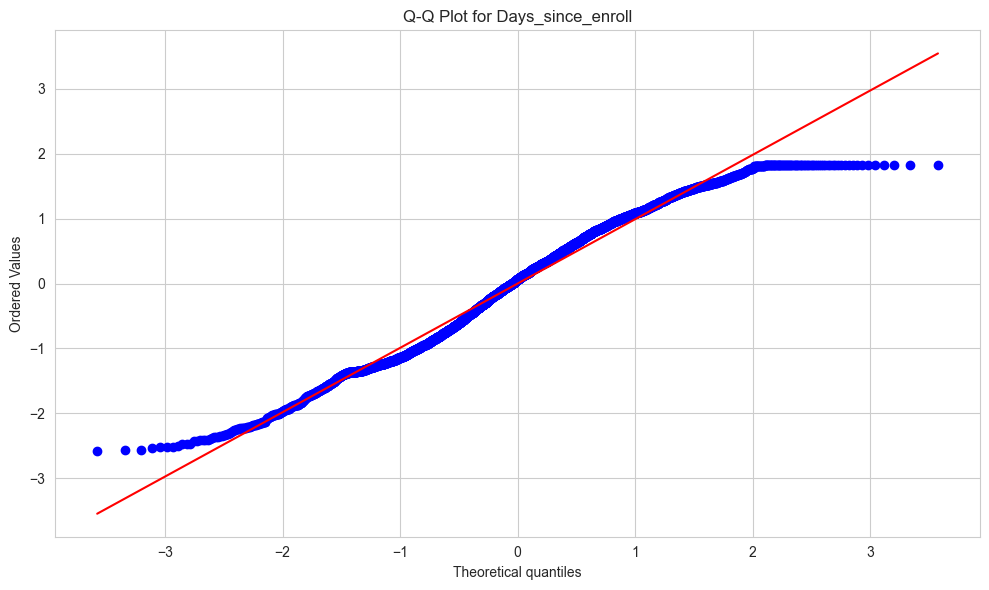

Shapiro-Wilk Test for Award?:
p-value: 0.0000
Award? does not appear to be normally distributed (reject H0)



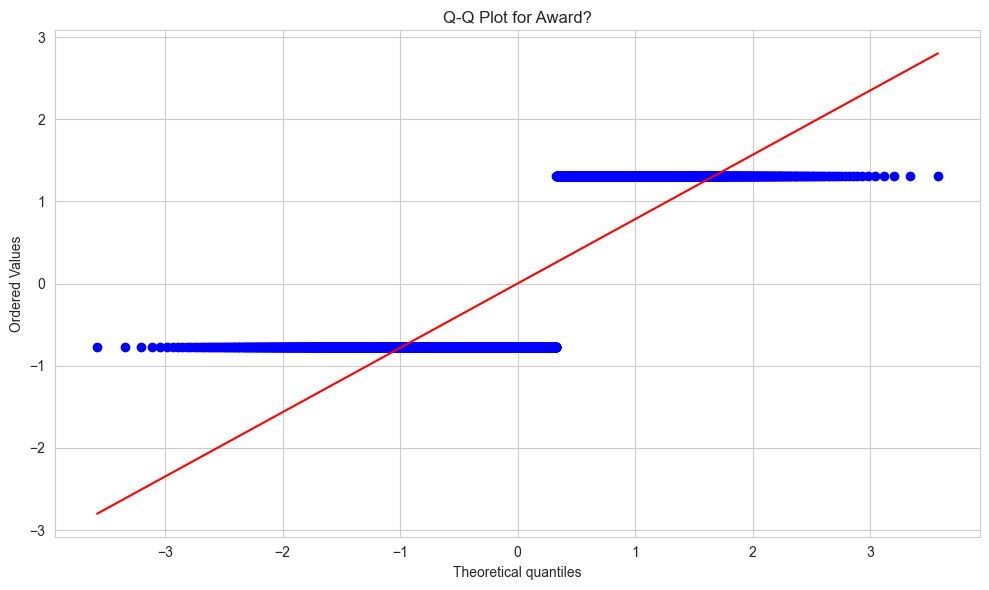


FEATURE ENGINEERING INSIGHTS

Skewness of Numerical Features:
ID#                 -0.289615
Balance              0.024477
Qual_miles           3.842612
cc1_miles            0.413166
cc2_miles            0.000000
cc3_miles            0.000000
Bonus_miles         -0.266623
Bonus_trans         -0.132616
Flight_miles_12mo    0.787724
Flight_trans_12      0.863188
Days_since_enroll   -0.156869
Award?               0.537200
dtype: float64

Kurtosis of Numerical Features:
ID#                  -1.007018
Balance               0.377208
Qual_miles           12.772053
cc1_miles            -1.708479
cc2_miles             0.000000
cc3_miles             0.000000
Bonus_miles          -0.636123
Bonus_trans          -0.669638
Flight_miles_12mo    -1.365491
Flight_trans_12      -1.143624
Days_since_enroll    -0.834872
Award?               -1.712272
dtype: float64


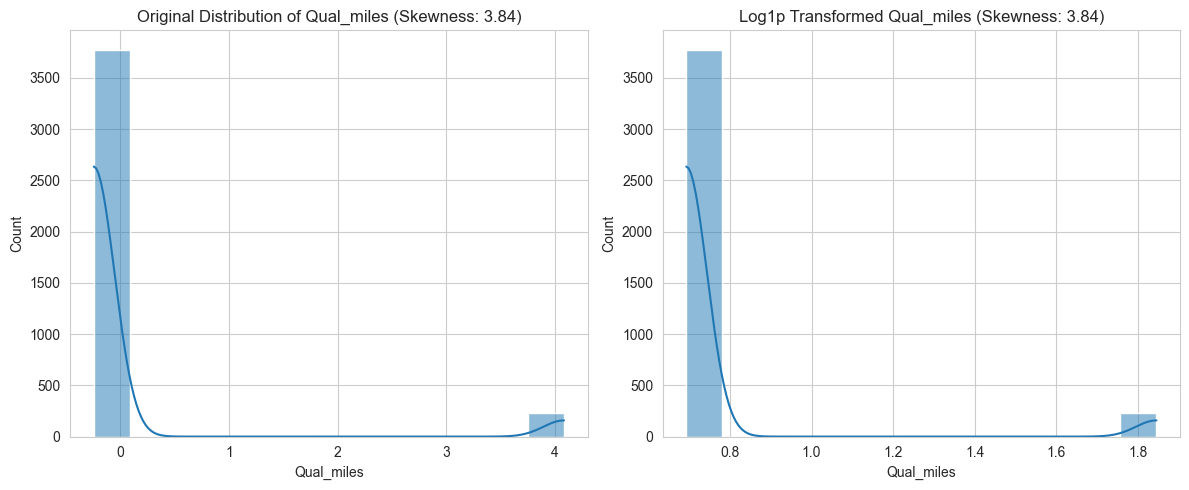


EDA COMPLETED


{'shape': (3999, 12),
 'missing': ID#                  0
 Balance              0
 Qual_miles           0
 cc1_miles            0
 cc2_miles            0
 cc3_miles            0
 Bonus_miles          0
 Bonus_trans          0
 Flight_miles_12mo    0
 Flight_trans_12      0
 Days_since_enroll    0
 Award?               0
 dtype: int64,
 'duplicates': 0,
 'numerical_columns': ['ID#',
  'Balance',
  'Qual_miles',
  'cc1_miles',
  'cc2_miles',
  'cc3_miles',
  'Bonus_miles',
  'Bonus_trans',
  'Flight_miles_12mo',
  'Flight_trans_12',
  'Days_since_enroll',
  'Award?'],
 'categorical_columns': []}

In [9]:
EDA(data)

In [10]:

def outlier_detection(data):
    columns = data.drop('ID#', axis=1).columns

    # Visualizing outliers with boxplots
    for col in columns: 
        plt.figure(figsize=(6,6))
        sns.boxplot(data=data, y=col, linewidth=0.75, palette='deep')
        plt.title(f"Boxplot of {col}")
        plt.ylabel(f"{col}")
        plt.show()

    # Detecting outliers using IQR method
    Q1 = data[columns].quantile(0.25)
    Q3 = data[columns].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR 
    upper_bound = Q3 + 1.5 * IQR

    iqr_outliers = data[((data[columns] < lower_bound) | (data[columns] > upper_bound)).any(axis=1)]
    return iqr_outliers


  

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2116\1318661327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, linewidth=0.75, palette='deep')


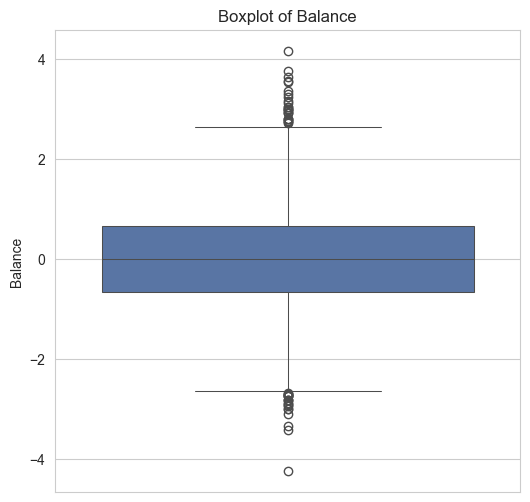

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2116\1318661327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, linewidth=0.75, palette='deep')


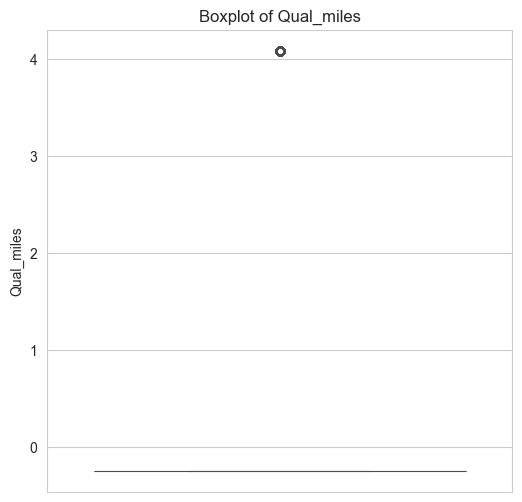

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2116\1318661327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, linewidth=0.75, palette='deep')


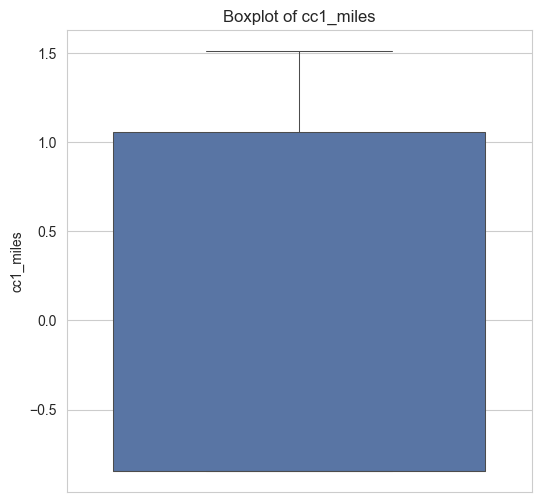

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2116\1318661327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, linewidth=0.75, palette='deep')


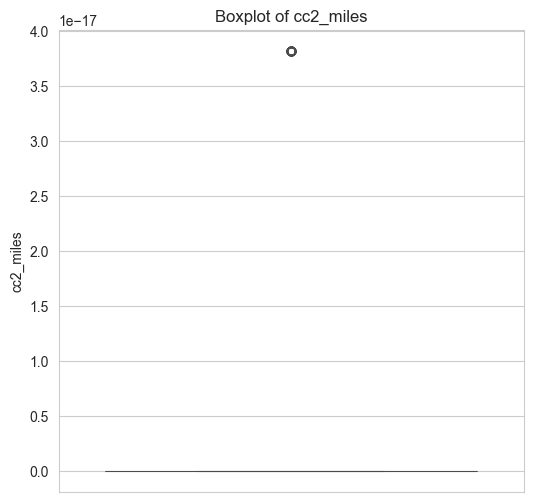

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2116\1318661327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, linewidth=0.75, palette='deep')


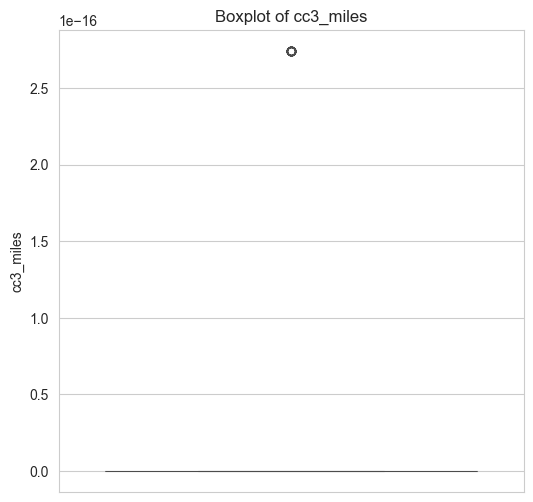

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2116\1318661327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, linewidth=0.75, palette='deep')


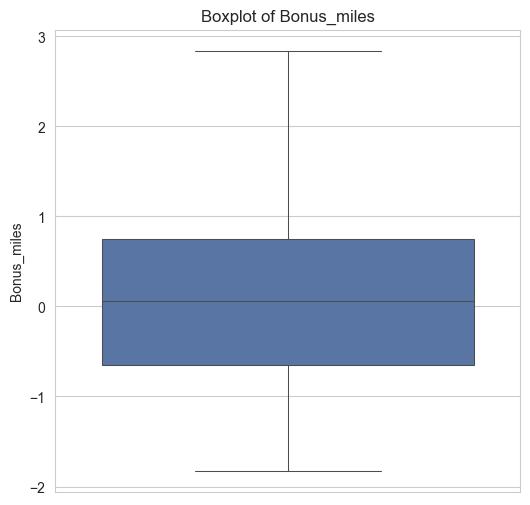

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2116\1318661327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, linewidth=0.75, palette='deep')


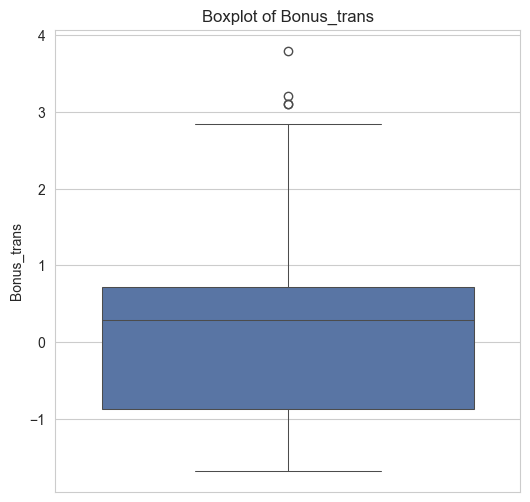

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2116\1318661327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, linewidth=0.75, palette='deep')


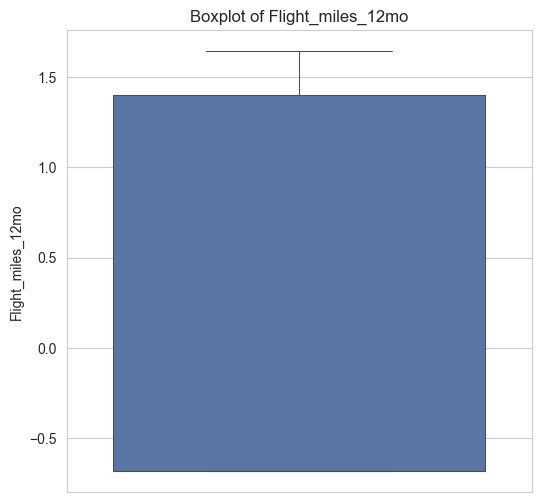

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2116\1318661327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, linewidth=0.75, palette='deep')


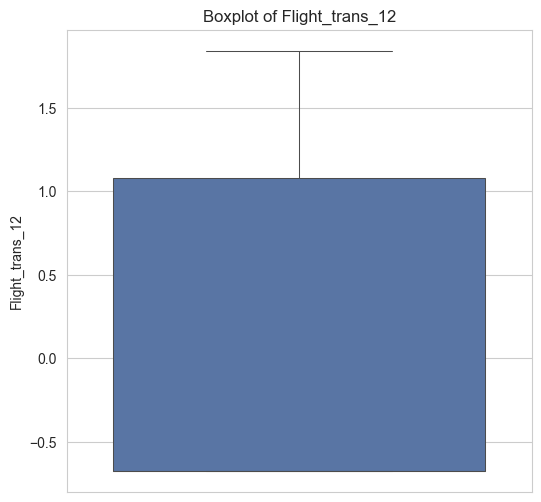

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2116\1318661327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, linewidth=0.75, palette='deep')


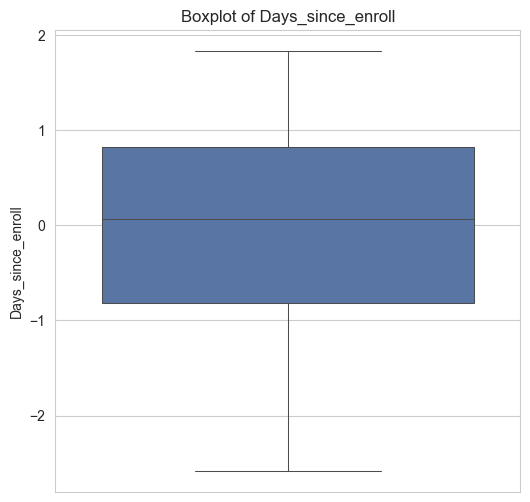

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2116\1318661327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y=col, linewidth=0.75, palette='deep')


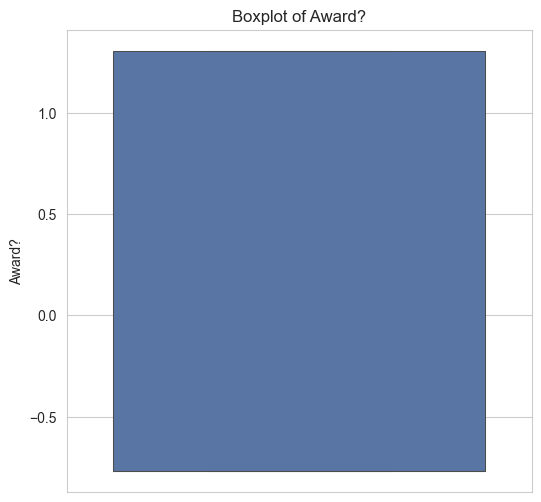

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
8,-2.142512,2.346543,-0.244743,1.058591,3.816392e-17,0.0,-0.532055,2.219525,1.579613,1.812556,1.300800,1.303918
21,-2.099932,1.364802,4.085914,-0.844766,0.000000e+00,0.0,0.395523,0.633734,1.540913,1.795290,1.279780,1.303918
24,-2.091253,1.473140,4.085912,-0.844766,0.000000e+00,0.0,-0.202441,1.005582,1.475586,1.685925,1.690710,-0.766919
43,-2.041654,2.763180,-0.244743,1.058591,0.000000e+00,0.0,0.465523,0.466669,-0.683308,-0.674970,1.646653,1.303918
45,-2.036832,1.846585,4.085914,-0.844766,0.000000e+00,0.0,0.745590,0.466669,1.546925,1.685925,1.274922,1.303918
...,...,...,...,...,...,...,...,...,...,...,...,...
3953,1.523917,0.277205,4.085913,-0.844766,0.000000e+00,0.0,-0.312790,-0.867299,-0.683308,-0.674970,-1.326383,1.303918
3956,1.525912,0.073647,4.085914,-0.844766,0.000000e+00,0.0,-0.147241,-0.688822,-0.683308,-0.674970,-1.326383,-0.766919
3959,1.527907,-0.862464,-0.244743,-0.844766,3.816392e-17,0.0,-0.034821,0.285696,-0.683308,-0.674970,-1.330133,-0.766919
3961,1.529236,1.008932,4.085913,-0.844766,0.000000e+00,0.0,-0.106291,0.188925,1.120654,1.081077,-1.339527,-0.766919


In [11]:
outlier_detection(data)

We have found outliers in [Flight_Trans_12], [Flight_miles_12mo], [Bonus_Trans], [Bonus_Miles], [Qual_Miles],[Balance]. 

In [12]:
#Outlier Treatment 

def yeo_johnson_transform(df, columns=None, standardize=True, inplace=False):
    """
    Applies Yeo-Johnson transformation to specified columns in a DataFrame.
    
    Parameters:
    - df (pd.DataFrame): Input DataFrame.
    - columns (list): List of column names to transform. If None, all numeric columns are used.
    - standardize (bool): Whether to standardize the output to mean=0 and variance=1 (default=True).
    - inplace (bool): Whether to modify the original DataFrame or return a new one (default=False).
    
    Returns:
    - pd.DataFrame: Transformed DataFrame.
    - dict: Optimal lambda (λ) values for each transformed column.
    """
    
    # Select numeric columns if no specific columns are provided
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()
    else:
        # Ensure specified columns exist and are numeric
        columns = [col for col in columns if col in df.columns and np.issubdtype(df[col].dtype, np.number)]
    
    # Copy the DataFrame if not modifying inplace
    if not inplace:
        df = df.copy()
    
    # Initialize PowerTransformer for Yeo-Johnson
    transformer = PowerTransformer(method='yeo-johnson', standardize=standardize)
    
    # Fit and transform the selected columns
    transformed_data = transformer.fit_transform(df[columns])
    
    # Update the DataFrame with transformed values
    df[columns] = transformed_data
    
    # Extract optimal lambdas (λ)
    lambdas = {col: lam for col, lam in zip(columns, transformer.lambdas_)}
    
    return df, lambdas



In [13]:
# Pass column names as strings inside a single list
transformed_df, lambdas = yeo_johnson_transform(
    data, 
    columns=['Flight_Trans_12', 'Flight_miles_12mo', 'Bonus_Trans', 'Bonus_Miles', 'Qual_Miles', 'Balance']
)


In [14]:
data.skew()

ID#                 -0.289615
Balance              0.024477
Qual_miles           3.842612
cc1_miles            0.413166
cc2_miles            0.000000
cc3_miles            0.000000
Bonus_miles         -0.266623
Bonus_trans         -0.132616
Flight_miles_12mo    0.787724
Flight_trans_12      0.863188
Days_since_enroll   -0.156869
Award?               0.537200
dtype: float64

In [15]:
transformed_df.skew()

ID#                 -0.289615
Balance              0.002704
Qual_miles           3.842612
cc1_miles            0.413166
cc2_miles            0.000000
cc3_miles            0.000000
Bonus_miles         -0.266623
Bonus_trans         -0.132616
Flight_miles_12mo    0.777275
Flight_trans_12      0.863188
Days_since_enroll   -0.156869
Award?               0.537200
dtype: float64

In [20]:
# outlier Treatment
transformed_df = transformed_df.drop(columns=['ID#'])

In [26]:
# Standard scalar Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(transformed_df), columns=transformed_df.columns)
scaled_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.343810,-0.244743,-0.844766,-0.104257,-0.067242,-1.178402,-1.329671,-0.684469,-0.674970,1.321776,-0.766919
1,-0.631251,-0.244743,-0.844766,-0.104257,-0.067242,-1.132416,-1.074960,-0.684469,-0.674970,1.308873,-0.766919
2,-0.034988,-0.244743,-0.844766,-0.104257,-0.067242,-0.191941,-0.688822,-0.684469,-0.674970,1.335468,-0.766919
3,-0.821219,-0.244743,-0.844766,-0.104257,-0.067242,-0.924946,-1.329671,-0.684469,-0.674970,1.302415,-0.766919
4,0.724991,-0.244743,1.343165,-0.104257,-0.067242,1.169363,1.329711,1.482308,1.685925,1.295549,1.303918


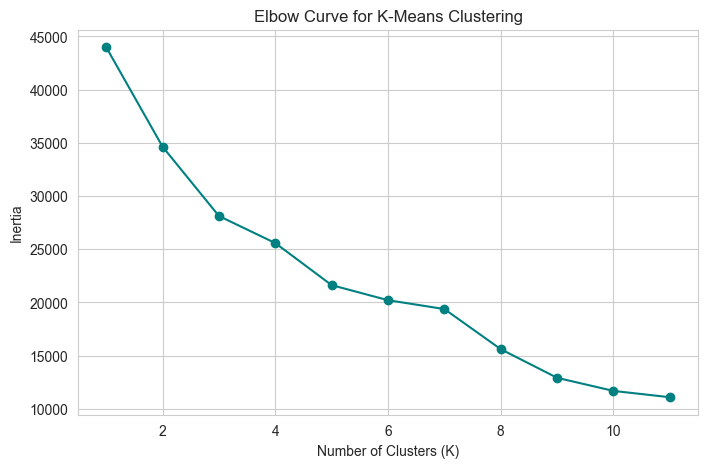

In [28]:
from sklearn.cluster import KMeans

# Experimenting with different K values using the Elbow curve
inertia_values = []
k_values = range(1, 12)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df) 
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o', color='teal')
plt.title('Elbow Curve for K-Means Clustering')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [51]:
from sklearn.cluster import AgglomerativeClustering

linkage_methods = ['ward', 'complete', 'average', 'single']

for method in linkage_methods:
    hierarchical = AgglomerativeClustering(n_clusters=3, linkage=method)
    hierarchical.fit(scaled_df)  
    labels = hierarchical.labels_
    print(f"Linkage Method: {method}")
    print("Cluster Labels:", labels)


Linkage Method: ward
Cluster Labels: [1 1 1 ... 0 2 1]
Linkage Method: complete
Cluster Labels: [0 0 0 ... 0 0 0]
Linkage Method: average
Cluster Labels: [0 0 0 ... 0 0 0]
Linkage Method: single
Cluster Labels: [2 2 2 ... 2 2 2]


In [40]:
from sklearn.cluster import DBSCAN

epsilon_values = [0.4,0.5,0.6]
minPts_values = [12,15,18,22] # Rule 1: minPts = 2 * dimensions, Rule 2: minPts = dimensions + 1 

results = []

for eps in epsilon_values:
    for minPts in minPts_values:
        dbscan = DBSCAN(eps=eps, min_samples=minPts)
        dbscan.fit(scaled_df)  
        labels = dbscan.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Exclude noise (-1)
        results.append((eps, minPts, n_clusters))

# Print results
for eps, minPts, n_clusters in results:
    print(f"Epsilon: {eps}, MinPts: {minPts}, Number of Clusters: {n_clusters}")


Epsilon: 0.4, MinPts: 12, Number of Clusters: 12
Epsilon: 0.4, MinPts: 15, Number of Clusters: 10
Epsilon: 0.4, MinPts: 18, Number of Clusters: 8
Epsilon: 0.4, MinPts: 22, Number of Clusters: 4
Epsilon: 0.5, MinPts: 12, Number of Clusters: 7
Epsilon: 0.5, MinPts: 15, Number of Clusters: 5
Epsilon: 0.5, MinPts: 18, Number of Clusters: 6
Epsilon: 0.5, MinPts: 22, Number of Clusters: 4
Epsilon: 0.6, MinPts: 12, Number of Clusters: 10
Epsilon: 0.6, MinPts: 15, Number of Clusters: 8
Epsilon: 0.6, MinPts: 18, Number of Clusters: 5
Epsilon: 0.6, MinPts: 22, Number of Clusters: 5


<h1>Intrepretation</h1>

- For __Kmeans clustering__ the elbow is at k = 4. Hence lets take K = 4 for K - means clustering.
- For __Hierarchical clustering__ 
        - The ward's method yielded Three cluters with maximum datapoints clustered around cluster 1.
        - The Complete linkage yielded two clusters.
        - Both single and average linkage only formed single cluster. 
- For __DBSCAN__ the most relevent clusters would be with parameters:
    1. Epsilon: 0.3, MinPts: 15, Number of Clusters: 6


      

C:\Users\KIIT\AppData\Local\Temp\ipykernel_2116\422262257.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', max(len(unique_labels)-1, 1))


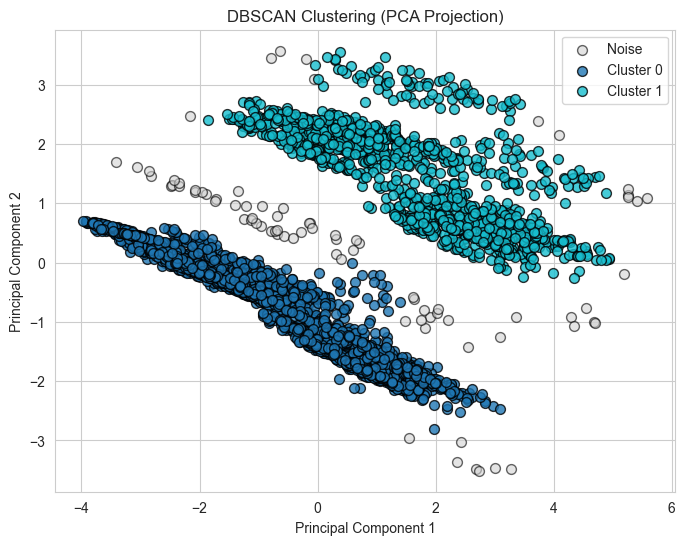

In [45]:
from sklearn.decomposition import PCA

# 1. Fit DBSCAN on your scaled data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_df)

dbscan = DBSCAN(eps=0.4, min_samples=12)
clusters = dbscan.fit_predict(X_pca)  

# 2. Reduce to 2D for plotting


# 3. Plot clusters + noise
plt.figure(figsize=(8, 6))
unique_labels = np.unique(clusters)
cmap = plt.cm.get_cmap('tab10', max(len(unique_labels)-1, 1))



for label in unique_labels:
    mask = (clusters == label)
    if label == -1:
        # noise
        plt.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c='lightgray', label='Noise',
            s=50, alpha=0.6, edgecolor='k'
        )
    else:
        # cluster points
        plt.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=[cmap(label)], label=f'Cluster {label}',
            s=50, alpha=0.8, edgecolor='k'
        )

plt.title("DBSCAN Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()


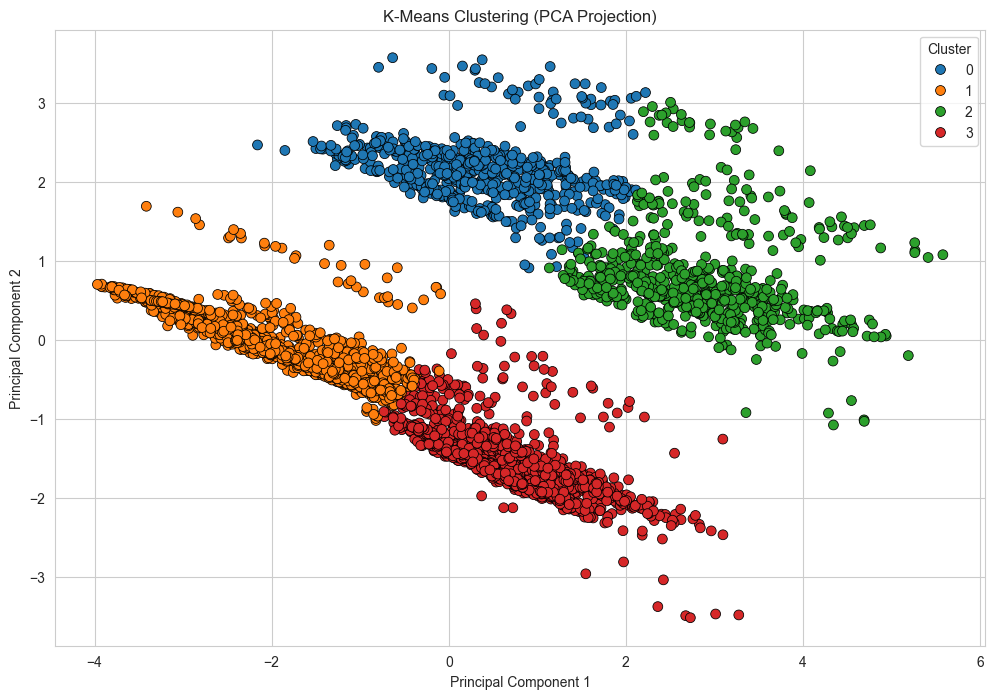

In [ ]:
#K means clustering scatter plot
k = 4 
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(scaled_df)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': labels  # NOT the whole array as a label, but per row
})

plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=50, edgecolor='black')
plt.title('K-Means Clustering (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

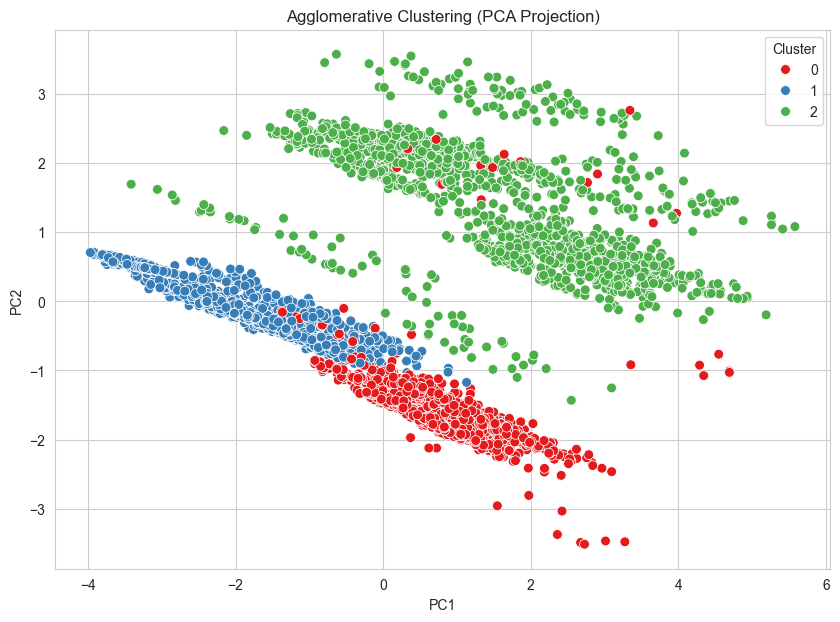

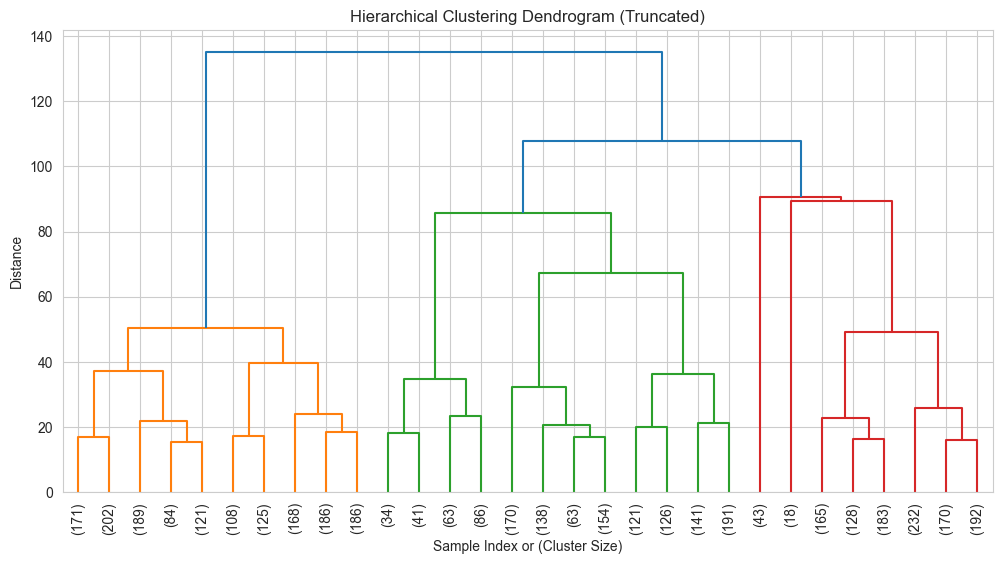

In [59]:
from scipy.cluster.hierarchy import dendrogram, linkage
#Agglomerative clustering
agglo_ward = AgglomerativeClustering(n_clusters=3,linkage='ward')
labels_ward = agglo_ward.fit_predict(scaled_df)


# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': labels_ward
})

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=50)
plt.title('Agglomerative Clustering (PCA Projection)')
plt.grid(True)
plt.show()

# linkage matrix using ward method (you can change to 'complete', 'average', etc.)
linked = linkage(scaled_df, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

In [60]:
#Silhoutte score
from sklearn.metrics import silhouette_score

# Calculate silhouette score for KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(scaled_df)
kmeans_labels = kmeans.labels_
silhouette_kmeans = silhouette_score(scaled_df, kmeans_labels)
print(f"KMeans Silhouette Score: {silhouette_kmeans:.4f}")

# Calculate silhouette score for Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=4, linkage='ward')
agglo.fit(scaled_df)
agglo_labels = agglo.labels_
silhouette_agglo = silhouette_score(scaled_df, agglo_labels)
print(f"Agglomerative Clustering Silhouette Score: {silhouette_agglo:.4f}")

# Calculate silhouette score for DBSCAN
dbscan = DBSCAN(eps=0.4, min_samples=12)
dbscan.fit(scaled_df)
dbscan_labels = dbscan.labels_
silhouette_dbscan = silhouette_score(scaled_df, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1
print(f"DBSCAN Silhouette Score: {silhouette_dbscan:.4f}")


KMeans Silhouette Score: 0.2923
Agglomerative Clustering Silhouette Score: 0.2791
DBSCAN Silhouette Score: -0.2602
